# Notebook 2 - Analysis & Reporting

Obejctif :

- Analyse Exploratoire & Business Analysis

Actions : 

-  Chargement des tables nettoyées

- Calcul des KPI

- Visualisations

- Interprétations business

- Conclusions

----------

## Sommaire 

0. Introduction
1. Importation des librairies et données
2. Aperçu des données de l'entreprise
3. Tendances mensuelles à travers des années (2023-2026)
4. Profil Client - Analyse comportementale
5. Synthèse
6. Recommandations
7. Conclusion
8. Compétences mobilisées


_____________

## 0. Introduction

Ce projet fait partie de ma candidature à la formation Data Analyst proposée par OpenClassrooms, et financée par France Travail, et s'inscrit dans le cadre de mon projet de reconversion professionnelle, accompagné et validé par un conseiller France Travail.

Le dataset utilisé dans ce projet contient le registre des transactions d'une entreprise fictive dans le secteur de la vente au détail.

L'objectif est d'identifier des dynamiques commerciales et des comportements clients afin de produire des insights exploitables pour la prise de décision.

Cette étude sera divisée en deux étapes : 

* La première partie (Notebook 1) sera dédiée au nettoyage et transformation des données, afin de les préparer pour l'analyse et d'éviter les anomalies ou les résultats biaisés.

* La deuxième partie (Notebook 2) se concentrera sur l'analyse exploratoire de ces données nettoyées et sur la compréhension des enjeux business à partir de l'identification des indicateurs clés de performance de l'entreprise : distribution du chiffre d'affaires, tendances mensuelles au fil des années, mesures de dispersion et de concentration. Cette étape permettra de définir une stratégie d'analyse et de répondre à des problématiques métier structurelles, avec l'identification d'actions potentielles.  

Remarques : 
Les données ont été enregistrées en anglais. Par souci de cohérence, les variables et valeurs resteront en anglais ; néanmoins, les résultats et interprétations seront communiqués en français. 

Les tables sont en format CSV (Comma-separated values ou valeurs séparées par virgule) et seront exploitées en Python dans un environnement Jupyter Notebook.

__________

## Présentation du Notebook 2 - Analysis & Reporting

Objectif :

L’objectif de cette deuxième partie du projet est d'exploiter les données afin d'en tirer des insights analytiques utiles pour le business et de contribuer à une meilleure performance de l'entreprise.

Elle sera basée sur les tables transactionnelles fact_sales_order (chaque ligne représentant une commande par client) et fact_sales (chaque ligne représentant un produit par commande), enrichies par les tables dimension dim_dates et dim_products.

Méthodologie : 

* Analyse descriptive des données : aperçu général, statistiques clés (totaux, moyennes, médianes, proportions, dispersion).

* Définition des hypothèses : identifier les tendances, comportements client et patterns commerciaux que les données pourraient révéler.

* Test les hypothèses : construire un récit analytique à partir des données et vérifier la validité des suppositions.

* Développement de calculs et visualisations : relations entre variables, corrélations, concentration, dispersion, distribution, segmentation clients ou produits.

* Conclusions et recommandations : produire des insights exploitables pour le business et formuler des actions stratégiques.

____________

## 1. Importation des librairies et données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import statsmodels.api as sm
import datetime as dt

In [2]:
#Chargement des tables nettoyées
fact_sales_order = pd.read_csv('../data/transformed/fact_sales_order.csv', parse_dates=['Order_Date'])
fact_sales = pd.read_csv('../data/transformed/fact_sales.csv', parse_dates=['Order_Date'])
dim_stores = pd.read_csv('../data/cleaned/dim_stores.csv')
dim_date = pd.read_csv('../data/transformed/dim_date.csv', parse_dates=['Order_Date'])
dim_products = pd.read_csv('../data/cleaned/dim_products.csv')

In [3]:
fact_order_date = fact_sales_order.merge(dim_date, on='Order_Date', how='left')

____________

## 2. Aperçu des données de l'entreprise

### 2.1 Inspection temporelle

Objectif :

- Identifier la distribution des commandes afin de comprendre la répartition des volumes sur la période disponible.

In [4]:
orders_distribution = (
    fact_order_date['Order_Year']
    .value_counts()
    .sort_index()
    .reset_index()
)
orders_distribution

,Order_Year,count
0,2016,16
1,2017,22
2,2018,18
3,2019,27
4,2020,21
5,2021,7
6,2023,3405
7,2024,4057
8,2025,3844
9,2026,583


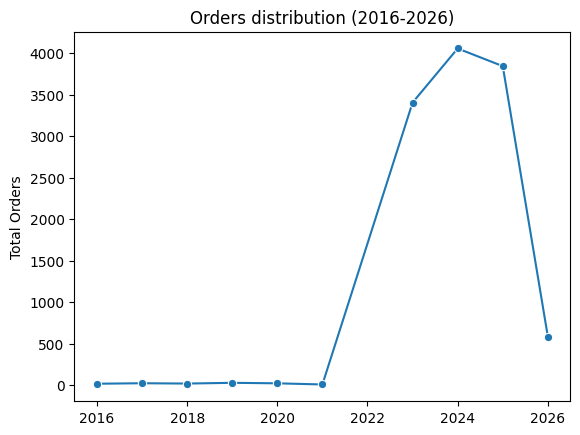

In [5]:
sns.lineplot(data=orders_distribution, x='Order_Year', y='count', marker='o')
plt.title('Orders distribution (2016-2026)')
plt.xlabel('')
plt.ylabel('Total Orders')
plt.show()

**Résultats et interprétation** 

* Les années 2016–2021 présentent des volumes très faibles (111 enregistrement au total).
* Aucune donnée n’est observée en 2022. 
* Puis un changement d’échelle majeur intervient dès 2023 (11 889 enregistrements).

Les données disponibles ne permettent pas d’identifier la cause de cette discontinuité (absence de variables explicatives).

**Conclusion provisoire** 

Pour éviter toute interprétation biaisée, l’analyse sera limitée à la période 2023–2026.

___________

### 2.1 Vue globale des indicateurs de performance (KPIs)

Objectif :

- Mesurer les indicateurs clés de l'activité (commandes, clients, chiffre d'affaires, panier) pour la période 2023-2026.

In [6]:
# Création de l'échantillon 2023-2026
df_after_2023 = fact_order_date[fact_order_date['Order_Year'] >= 2023]

In [7]:
#Calcul des KPIs

#Période couverte par les données
period_start = df_after_2023['Order_Date'].min()
period_end = df_after_2023['Order_Date'].max()

#Volume d'activité
total_orders = df_after_2023['Order_ID'].nunique()
total_units = df_after_2023['Quantity'].sum()
total_customers = df_after_2023['Customer_ID'].nunique()

#Revenus
gross_revenue = df_after_2023['Total_Gross'].sum()
net_revenue = df_after_2023['Total_Net'].sum()
total_discount = df_after_2023['Discount_Amount'].sum()

#KPIs dérivés
aov = net_revenue/total_orders
mov = df_after_2023['Total_Net'].median()
discount_rate = total_discount/gross_revenue*100
avg_units_per_order = total_units/total_orders

In [8]:
business_overview = pd.DataFrame({
    'Metric' : [
        'Period Start',
        'Period End',
        'Total Orders',
        'Total Customers',
        'Gross Revenue',
        'Net Revenue',
        'Average Order Value (AOV)',
        'Median Order Value (MOV)',
        'AOV/MOV',
        'Discount Rate',
        'Total Units Sold',
        'Average Units per Order'
    ],
    'Value': [
        period_start.date(),
        period_end.date(),
        total_orders,
        total_customers,
        gross_revenue,
        net_revenue,
        aov,
        mov,
        aov/mov,
        discount_rate,
        total_units,
        avg_units_per_order,
    ]
})
business_overview.round(2)

,Metric,Value
0,Period Start,2023-02-23
1,Period End,2026-02-23
2,Total Orders,11889
3,Total Customers,4568
4,Gross Revenue,16878820.86
5,Net Revenue,15911429.44
6,Average Order Value (AOV),1338.332025
7,Median Order Value (MOV),607.05
8,AOV/MOV,2.204649
9,Discount Rate,5.731392


**Résultats**

Sur la période entre février 2023 – février 2026, l’entreprise enregistre 11 889 commandes pour 4 568 clients distincts, soit en moyenne d'environ 9,6 unités par commande.

Le chiffre d’affaires net est de 15.911.429,44€, après application de remises correspondant à ~5,73% du chiffre d’affaires brut (16.878.820,86€).

**Interprétation**

* L’écart important entre le panier moyen - AOV (1338€) et le panier médian - MOV(607€) indique une distribution asymétrique : quelques commandes très élevées tirent la moyenne vers le haut.

* Le panier médian représente mieux le panier "typique" d'un client.

__________

### 2.2 Analyse de la dispersion

Objectif :

- Observer la dispersion du chiffre d'affaires pour détecter asymétries et valeurs extrêmes.

##### 2.2.1 Visualisation - Distribution du chiffre d'affaires (par histogramme) 

In [9]:
#basic stats : distribution chiffre d'affaires Net
df_after_2023['Total_Net'].describe().reset_index()

,index,Total_Net
0,count,11889.000000
1,mean,1338.332025
2,std,2360.294564
3,min,4.700000
4,25%,218.790000
5,50%,607.050000
6,75%,1430.670000
7,max,27356.640000


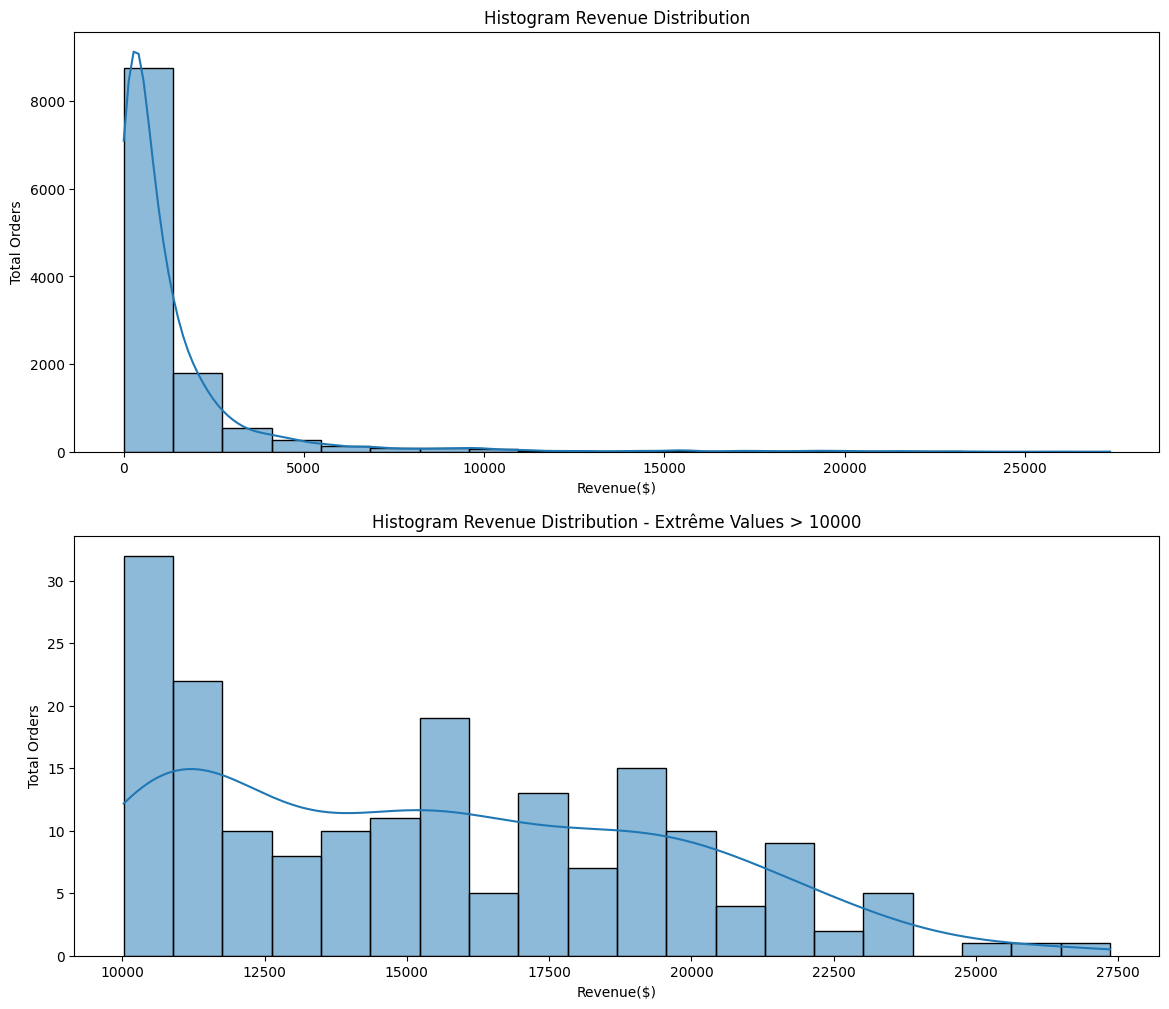

In [87]:
#Histogramme Distribution chiffre d'affaires Net
plt.figure(figsize=(14,12))

ax1 = plt.subplot(2, 1, 1)
sns.histplot(df_after_2023['Total_Net'], bins=20, kde=True, ax=ax1)
plt.title("Histogram Revenue Distribution")
plt.xlabel("Revenue($)")
plt.ylabel('Total Orders')

ax2 = plt.subplot(2, 1, 2)
sns.histplot(df_after_2023[df_after_2023['Total_Net']>10000]['Total_Net'], bins=20,kde=True, ax=ax2)
plt.title("Histogram Revenue Distribution - Extrême Values > 10000")
plt.xlabel("Revenue($)")
plt.ylabel('Total Orders')

plt.show()

**Histogramme**  

*Graphique 1* : La distribution est fortement étalée à droite, avec la majorité des commandes entre ~5 € – 1 500 €. 

*Graphique 2* : Quelques commandes très élevées (>10 000 €) tirent la moyenne vers le haut.

##### 2.2.2 Visualisation - Dispersion du chiffre d'affaires (par boîte à moustache) 

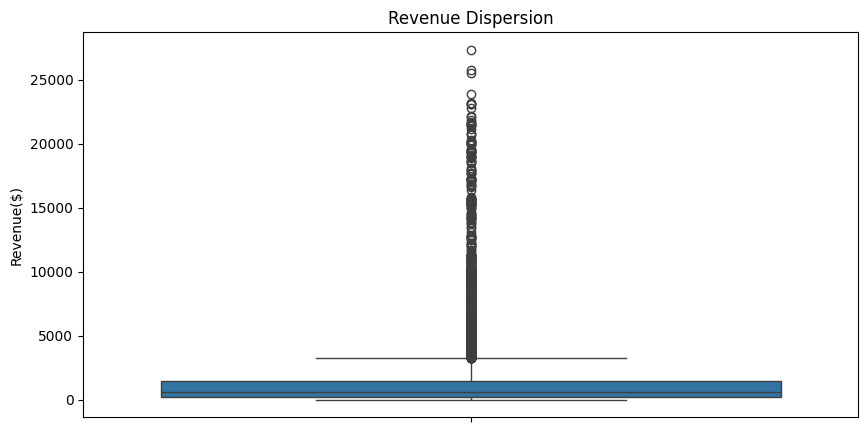

In [88]:
#Mesure de Dispersion du chiffre d'affaires Net
plt.figure(figsize=(10,5))
sns.boxplot(df_after_2023['Total_Net'])
plt.title("Revenue Dispersion")
plt.ylabel("Revenue($)")
plt.show()

**Boxplot** : 

*Graphique 3* : Cette boîte à moustache montre que jusqu’au troisième quartile,75% des commandes restent dans une fourchette modérée. Tandis que les 25% supérieures créent longues “queues”, qui compriment la visualisation des petits paniers.

**Conclusion provisoire** :

La dispersion élevée indique la présence de commandes de montant exceptionnellement important, qui seront analysées plus en détail dans la suite.

____________

### 2.3 Synthèse et plan d’analyse pour la suite

**Résumé**

1. Volumes très faibles 2016-2022, rupture nette à partir de 2023.
2. Forte dispersion du chiffre d'affaires, avec un écart marqué entre le panier moyen (AOV) et la médiane (MOV), ce qui suggère la présence de commandes très élevées. 

**Plan pour la suite**

* Concentration sur la période 2023–2026.

* Analyse des tendances mensuelles pour observer l’évolution des revenus et du nombre de commandes.

__________

## 3. Tendances mensuelles sur plusieurs années

Objectif :

- Analyser l’évolution mensuelle du chiffre d’affaires et du volume de commandes sur 2023–2026.

___________

### 3.1 Tendance mensuelle continue

Objectif : 

- Analyser la dynamique mensuelle dans le temps. 

Granularité : chaque mois sur toute la période, en temps continu (timeline complète).

In [12]:
df_monthly_kpis = (
    df_after_2023.set_index('Order_Date')
    .resample('ME')
    .agg({'Total_Net':[
        'sum',
        'mean',
        'median',
        'count'],
        'Customer_ID': 'nunique'
        })
        .round(2)
)

df_monthly_kpis.columns = [
    'Total_Revenue', 
    'Avg_Revenue',
    'Median_Revenue',
    'Total_Orders',
    'Active_Customers'
]

La méthode ```.resample()``` regroupe les transactions par mois se terminant à la fin du mois pour obtenir une timeline continue.

__________

#### 3.1.1 Visualisation - Evolution mensuelle sur la période (par graphique linéaire)

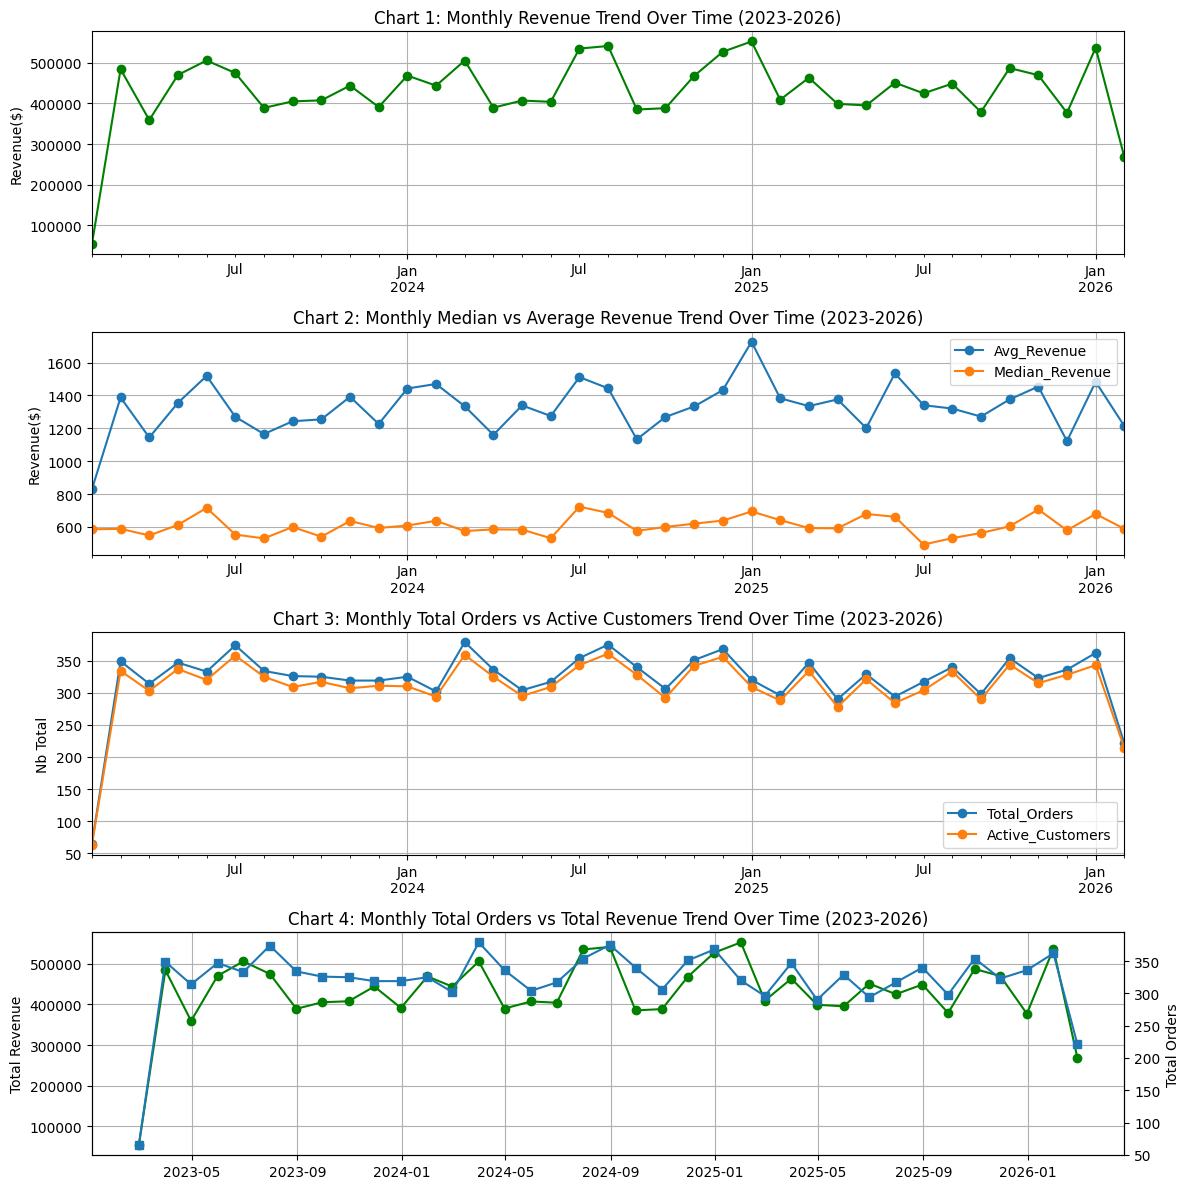

In [208]:
#Visualisation
plt.figure(figsize=(12,12))

ax1 = plt.subplot(4, 1, 1)
df_monthly_kpis['Total_Revenue'].plot(marker='o', grid=True, ax=ax1, color='green')
plt.title('Chart 1: Monthly Revenue Trend Over Time (2023-2026)')
plt.xlabel('')
plt.ylabel('Revenue($)')

ax2 = plt.subplot(4, 1, 2)
df_monthly_kpis[['Avg_Revenue','Median_Revenue']].plot(marker='o', grid=True, ax=ax2)
plt.title('Chart 2: Monthly Median vs Average Revenue Trend Over Time (2023-2026)')
plt.xlabel('')
plt.ylabel('Revenue($)')

ax3 = plt.subplot(4, 1, 3)
df_monthly_kpis[['Total_Orders', 'Active_Customers']].plot(marker='o', grid=True, ax=ax3)
plt.title('Chart 3: Monthly Total Orders vs Active Customers Trend Over Time (2023-2026)')
plt.xlabel('')
plt.ylabel('Nb Total')


#Axe principal (Revenue)
axre = plt.subplot(4,1,4)
axre = plt.gca()
axre.plot(df_monthly_kpis.index, df_monthly_kpis['Total_Revenue'], marker='o', color='green')
axre.set_title('Chart 4: Monthly Total Orders vs Total Revenue Trend Over Time (2023-2026)')
axre.set_ylabel('Total Revenue')
axre.set_xlabel('')
axre.grid(True)

#Axe secondaire (Orders)
axord = axre.twinx()
axord.plot(df_monthly_kpis.index, df_monthly_kpis['Total_Orders'], marker='s')
axord.set_ylabel('Total Orders')

plt.tight_layout()
plt.show()

**Interprétation**

Chaque point de ce graphique correspond à un mois de l'année. 

Les revenus et commandes augmentent fortement à partir de février/mars 2023, puis restent globalement stables avec des fluctuations mensuelles normales. La médiane reste stable, la moyenne tirée par quelques gros paniers. La croissance semble principalement volume-driven, avec des effets panier ponctuels.


**Conclusion provisoire**

La rupture observée en 2023 suggère que la croissance est principalement tirée par l’augmentation des volumes, plutôt que par une hausse du panier moyen ou une évolution du mix produit.

La suite de l’analyse examinera les tendances mensuelles par année pour observer la dynamique du chiffre d'affaires et du nombre de commandes sur chaque année.

_________

### 3.2 Comparaison interannuelle mensuelle

Objectif :

- Comparer chaque mois d’années différentes, pour identifier patterns saisonniers ou anomalies.

Granularité : mois séparés par année, non continu dans le temps.

In [14]:
#vue mensuelle
df_monthly_yoy_kpis = (
    df_after_2023
    .groupby([
        'Order_Year', 
        'Order_Month'
        ])
        .agg({
        'Total_Net':[
        'sum',  
        'count'],
        'Customer_ID':'nunique'
        })
        . reset_index()
)
df_monthly_yoy_kpis.columns = [
    'Order_Year', 
    'Order_Month',
    'Total_Revenue', 
    'Total_Orders',
    'Active_Customers'
    ]
df_monthly_yoy_kpis['Orders/Customers'] = (
    df_monthly_yoy_kpis['Total_Orders'] / 
    df_monthly_yoy_kpis['Active_Customers']
) 

Cette vue servira de base pour comparer les performances par mois et analyser la dynamique des commandes.

In [15]:
#ratio de commandes par client actif
ratio = df_monthly_yoy_kpis.pivot_table(
    index='Order_Month',
    columns='Order_Year',
    values='Orders/Customers'
)
ratio.round(2)

Order_Year,2023,2024,2025,2026
Order_Month,,,,
1,NaN,1.05,1.04,1.06
2,1.03,1.03,1.03,1.03
3,1.04,1.06,1.04,NaN
4,1.04,1.03,1.04,NaN
5,1.03,1.03,1.02,NaN
6,1.04,1.03,1.04,NaN
7,1.04,1.03,1.04,NaN
8,1.03,1.04,1.02,NaN
9,1.06,1.04,1.03,NaN


La moyenne des commandes par client reste stable, suggérant que la croissance du chiffre d’affaires provient plutôt de l’augmentation du nombre de clients ou de commandes à panier élevé.

________

#### 3.2.1 Visualisation - Evolution du chiffre d'affaires mensuel par année (par carte de chaleur et graphique linéaire)

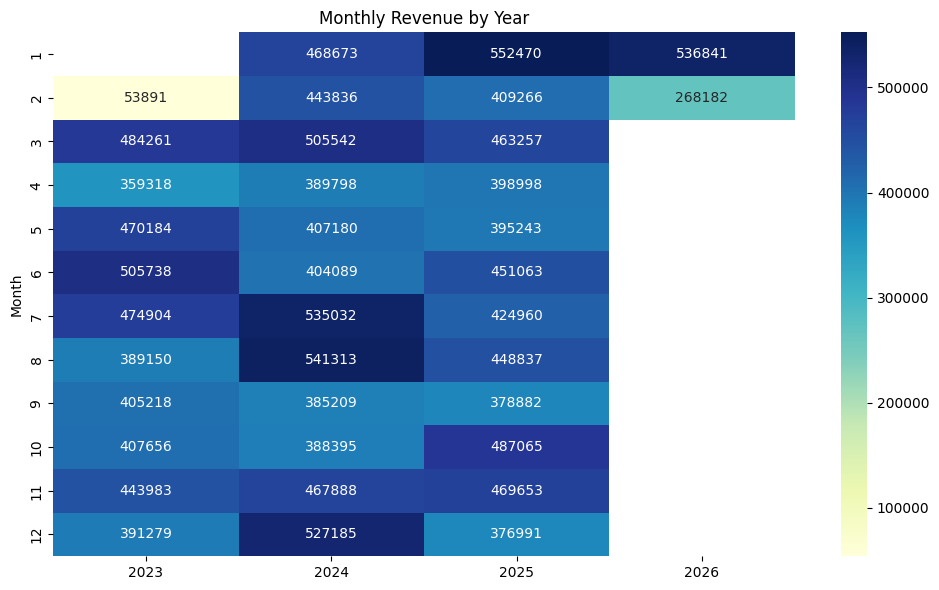

In [90]:
#Heatmap CA par mois/année
heatmap_data = df_monthly_yoy_kpis.pivot_table(
    index='Order_Month',
    columns='Order_Year',
    values='Total_Revenue'
)

plt.figure(figsize=(10,6))

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title("Monthly Revenue by Year")
plt.xlabel("")
plt.ylabel("Month")

plt.tight_layout()
plt.show()

*Graphique 1* : Cette heatmap (carte de chaleur) permet de mettre en évidence visuellement et quantitativement les anomalies et régularités sur la période de manière immédiate.

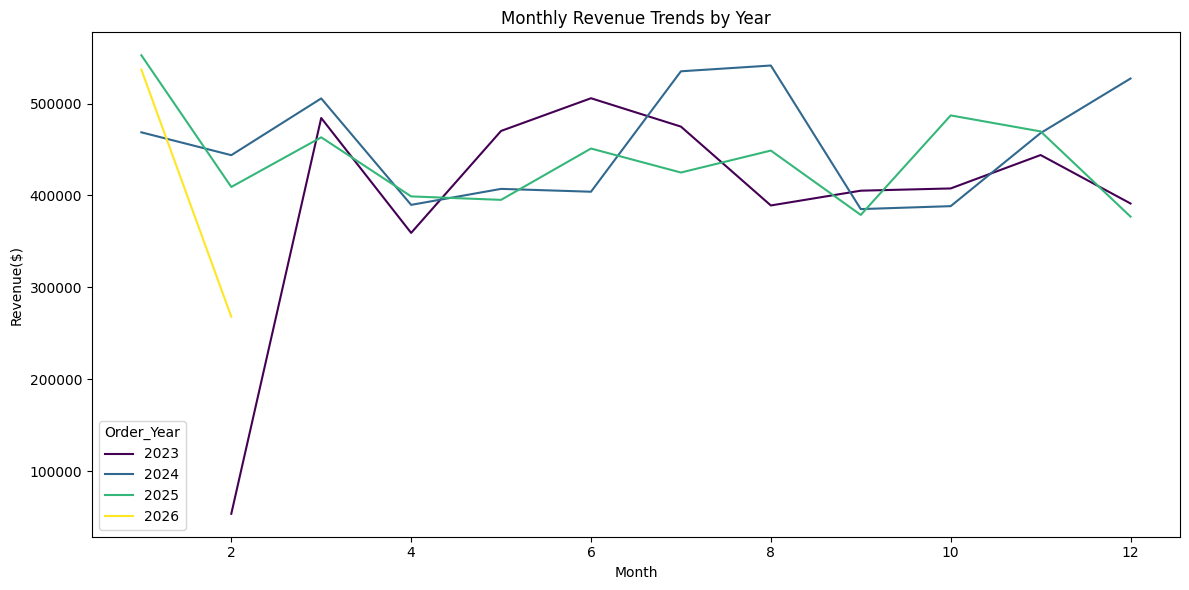

In [91]:
#lineplot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_monthly_yoy_kpis,
    x='Order_Month',
    y='Total_Revenue',
    hue='Order_Year',
    palette='viridis'
)
plt.title('Monthly Revenue Trends by Year')
plt.xlabel('Month')
plt.ylabel('Revenue($)')

plt.tight_layout()
plt.show()

*Graphique 2* : Ce lineplot (graphique en ligne) montre la forme des tendances dynamiques pour chaque année, mois par mois, pour raconter l’évolution et les variations du chiffre d'affaires.

**Résultats**

- Les revenus de février 2023 sont très faibles (53 891 €) par rapport aux années suivantes - reflet du démarrage d’activité.

- Pour les mois de mars à décembre, les revenus sont globalement stables d’une année sur l’autre, avec quelques variations normales.

- Les pics observés en juillet et août 2024 suggèrent une saisonnalité légère ou une variation ponctuelle de l’activité.

- Les mois 1 et 2 de 2026 montrent une baisse notable par rapport aux années précédentes, indiquant un début d’année plus faible.

**Conclusion provisoire**

Pas de saisonnalité forte détectée, mais quelques variations ponctuelles.

Anomalies notables : faible revenu en février 2023 et le début 2026.

________

### 3.3 KPI annuels 2023-2026

In [18]:
df_after_2023_kpis_summary = (
    df_after_2023
    .groupby('Order_Year')
    .agg(
        Active_Customers = ('Customer_ID','nunique'),
        Total_Orders = ('Order_ID','nunique'),
        Total_Units = ('Quantity', 'sum'), 
        Avg_Units = ('Quantity','mean'),
        Median_Units = ('Quantity','median'),
        Avg_Revenue = ('Total_Net','mean'),
        Median_Revenue = ('Total_Net','median'),
        Total_Revenue = ('Total_Net','sum')
        )
    .reset_index()
)

df_after_2023_kpis_summary['Revenue_%'] = ((
    df_after_2023_kpis_summary['Total_Revenue']/
    net_revenue)*100
)

df_after_2023_kpis_summary['Orders/Customers'] = (
    df_after_2023_kpis_summary['Total_Orders']/
    df_after_2023_kpis_summary['Active_Customers']
)

df_after_2023_kpis_summary.round(2)

,Order_Year,Active_Customers,Total_Orders,Total_Units,Avg_Units,Median_Units,Avg_Revenue,Median_Revenue,Total_Revenue,Revenue_%,Orders/Customers
0,2023,2458,3405,32023,9.40,6.0,1287.98,592.07,4385580.67,27.56,1.39
1,2024,2809,4057,39271,9.68,6.0,1346.84,610.15,5464140.25,34.34,1.44
2,2025,2682,3844,36880,9.59,6.0,1367.50,618.32,5256684.99,33.04,1.43
3,2026,543,583,5835,10.01,7.0,1380.83,633.93,805023.53,5.06,1.07


**En résumé**

* La synthèse annuelle confirme que la croissance 2023-2024 est portée par le nombre de clients actifs et du volume de commandes, tandis que le panier médian reste stable. 

* La moyenne légèrement croissance reflète quelques commandes à montant élevé

**Hypothèse à tester** 

À ce stade, trois hypothèses principales peuvent être envisagées pour expliquer la croissance du chiffre d'affaires :

1. L'acquisition des nouveaux clients ?

2. L'augmentation de la fréquence d'achat des clients existants ?

3. La concentration des achats sur certains segments ou produits ?

L’analyse du comportement des clients dans la section suivante permettra de vérifier ces hypothèses.

_______

## 4. Profil Client - Analyse comportementale

Objectif :

* Identifier si la croissance est tirée par les nouveaux clients ou les clients existants.

* Observer l'impact des segments clients sur le chiffre d'affaires et le volume.

* Vérifier si certains segments concentrent de manière disproportionnée le chiffre d'affaires.

_________

#### 4.1 Construction du RFM Panel

Objectif :

- Identifier les profils clients selon :

    * leur activité récente

    * leur fréquence d’achat

    * leur contribution au chiffre d’affaires.

Méthodologie :

* Recency (Récence) = jours depuis dernière commande. Mesure d'interaction.
* Frequency (Fréquence) = nombre total de commandes par client. Mesure d’engagement.
* Monetary_Net (Monétaire) = chiffre d'affaires (CA) cumulé par client.
* Cohort_Date = mois de la première commande. Utile pour analyse d’acquisition.

In [19]:
#table RFM de reference
reference_date = df_after_2023['Order_Date'].max()

df_rfm = (
    df_after_2023.groupby(['Customer_ID'])
    .agg(
        Frequency = ('Order_ID', 'nunique'),
        Cohort_Date = ('Order_Year_Month','min'),
        Recency = ('Order_Date', lambda x:(reference_date - x.max()).days),
        Monetary_Net = ('Total_Net', 'sum')
    )
)

df_rfm = df_rfm.reset_index()


Le panel RFM couvre 4 568 clients actifs post-2023. Il servira à segmenter les clients par fréquence (par la suite), analyser la contribution au CA et tester les hypothèses sur l'origine de la croissance observée.

_________

#### 4.2 Segmentation par Fréquence

Objectif :

- Analyser la distribution des clients selon leur fréquence d'achat afin d'identifier le poids de chaque segment sur le chiffre d'affaires.

Méthodologie :

* One-Timer = 1 seule commande 
* Occasional = entre 2 et 4 commandes
* Recurrent = 5+ commandes

In [20]:
df_rfm['Frequency_Seg'] = np.where(
    df_rfm['Frequency'] == 1,
    'One-timer',
    np.where(
        df_rfm['Frequency'] >= 5,
        'Recurrent',
        'Occasional'
    )
)

In [21]:
df_frequency = (
    df_rfm
    .groupby('Frequency_Seg')
    .agg(
        Total_Customers = ('Customer_ID', 'nunique'),
        Frequency = ('Frequency', 'sum'),
        Monetary = ('Monetary_Net', 'sum')
    )
)
df_frequency['AOV'] = df_frequency['Monetary']/df_frequency['Frequency']
df_frequency['Customer_%'] = df_frequency['Total_Customers']/total_customers*100
df_frequency['Monetary_%'] = df_frequency['Monetary']/net_revenue*100

df_frequency.round(2)

,Total_Customers,Frequency,Monetary,AOV,Customer_%,Monetary_%
Frequency_Seg,,,,,,
Occasional,2945,8160,11055721.34,1354.87,64.47,69.48
One-timer,1155,1155,1458526.50,1262.79,25.28,9.17
Recurrent,468,2574,3397181.60,1319.81,10.25,21.35


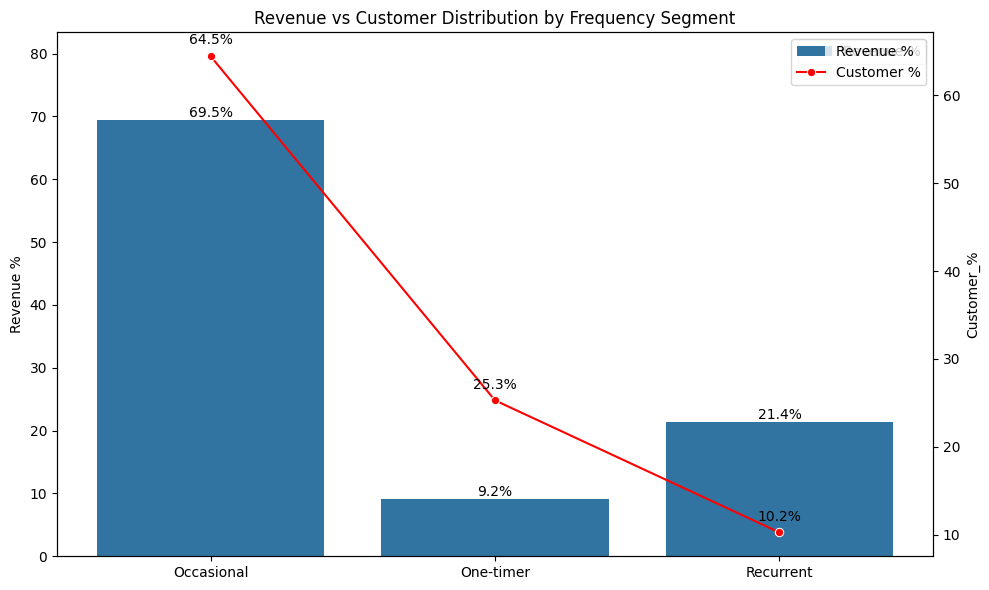

In [22]:
fig, ax1 = plt.subplots(figsize=(10,6))
#axe primaire %CA
sns.barplot(data=df_frequency, x='Frequency_Seg', y='Monetary_%', label='Revenue %', ax=ax1)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='edge')

ax1.set_ylabel('Revenue %')
ax1.set_xlabel('')
ax1.set_ylim(0,max(df_frequency['Monetary_%'].max(), df_frequency['Customer_%'].max())*1.2)

#axe secondaire %clients
ax2 = ax1.twinx()
sns.lineplot(data=df_frequency, x='Frequency_Seg', y='Customer_%', color='red',marker='o', label='Customer %', ax=ax2)
for i, value in enumerate(df_frequency['Customer_%']):
    ax2.text(i, value + 1, f'{value:.1f}%', color='black', ha='center', va='bottom')

#légende combinée
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines+lines2, labels+labels2, loc='upper right')

plt.title('Revenue vs Customer Distribution by Frequency Segment')
plt.tight_layout()
plt.show()

**Résultats**

* Le segment Occasional constitue la majorité des clients (+64%) et génère 69% du chiffre d'affaires global, ce qui en fait le segment le plus important en termes de volume de CA.

* Le segment Recurrent représente seulement 10 % des clients, mais contribue à 21 % du chiffre d’affaires, avec un panier moyen par commande légèrement supérieur à 1 318 €. 

* Le segment One-timer concentre 25% des clients pour uniquement 9% CA, avec le panier moyen le plus faible.

**Conclusion**

La contribution au chiffre d’affaires est principalement portée par le segment des clients Occasionals.

La dépendance à un segment ultra-minoritaire n’est pas structurellement dominante à ce stade.

_____________

#### 4.3 Analyse d'Acquisition 

Objectif : 

- Mesurer la contribution des nouveaux clients à la croissance du chiffre d’affaires, année par année, en comparant le revenu et le nombre de clients acquis par cohorte.

##### 4.3.1 Tableau d'acquisition des nouveau clients par cohorte

In [23]:
df_rfm[['Cohort_Year','Cohort_Month']] = df_rfm['Cohort_Date'].str.split('-', expand=True).astype(int)

df_acquisition = (
    df_rfm
    .groupby(['Cohort_Year', 'Cohort_Month'])
    .agg(
        Total_Customers = ('Customer_ID','nunique'), 
        Total_Orders = ('Frequency','sum'), 
        Total_Revenue = ('Monetary_Net','sum')
        )
        .reset_index()
)

df_acquisition['Cohort_Month'] = 'M' + df_acquisition['Cohort_Month'].astype(str)

df_acquisition['Acquisition_%'] = (df_acquisition['Total_Customers']/total_customers)*100
df_acquisition['Revenue_%'] = (df_acquisition['Total_Revenue']/net_revenue)*100

##### 4.3.2 Taux d’acquisition par cohorte

In [24]:
acquisition_rate = (
    df_acquisition
    .groupby('Cohort_Year')[['Total_Customers','Acquisition_%','Revenue_%']]
    .sum()
    .reset_index()
).round(2)
acquisition_rate

,Cohort_Year,Total_Customers,Acquisition_%,Revenue_%
0,2023,2458,53.81,64.21
1,2024,1446,31.65,27.00
2,2025,600,13.13,8.08
3,2026,64,1.40,0.71


* ~54% des clients acquis en 2023 ont contribué à ~64% du CA.
* ~31% des nouveaux clients en 2024 ont participé à 27% du CA.
* ~13% des clients de la cohorte 2025 ont généré ~8% du CA.
* Données partielles pour 2026.

Ces chiffres permettent d’observer la dynamique d’acquisition par cohorte et sa contribution au chiffre d’affaires global.

_________

##### 4.3.3 Visualisation - Analyse de l'Acquisition par cohorte (par carte de chaleur)

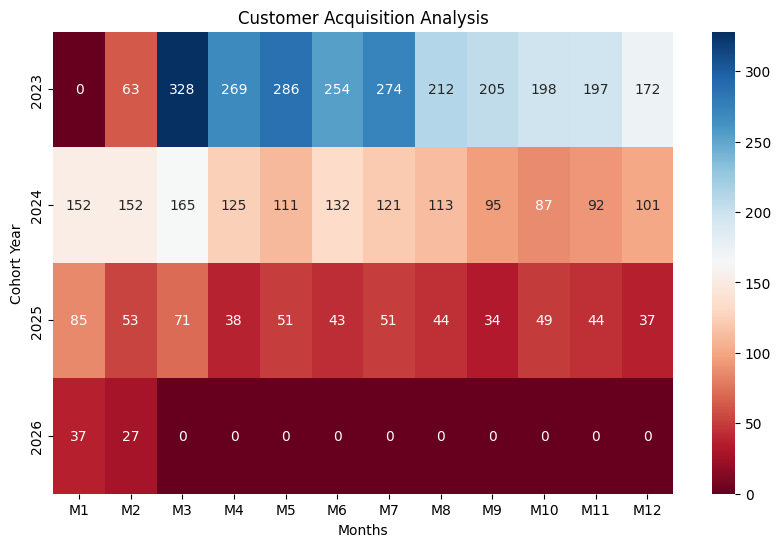

In [92]:
acquisition_pivot = (
    df_acquisition
    .pivot_table(
        index='Cohort_Year',
        columns='Cohort_Month',
        values='Total_Customers',
        fill_value=0
    )
)
columns = ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12']
acquisition_pivot = acquisition_pivot.reindex(columns=columns)

plt.figure(figsize=(10,6))
sns.heatmap(acquisition_pivot, annot=True, fmt='.0f',cmap='RdBu')
plt.title('Customer Acquisition Analysis')
plt.ylabel('Cohort Year')
plt.xlabel('Months')
plt.show()

**Interprétation** 

La heatmap illustre le nombre de clients acquis chaque mois par cohorte, permettant de visualiser la répartition temporelle des nouvelles acquisitions.

Forte acquisition de clients en mars 2023 qui continue jusqu'à la fin de l'année, avec une baisse à partir de novembre. Tout au long de 2024 reste stable avec des légères baisses chaque mois, ce qui engendre dans une très faible acquisition durant 2025 et minime ce début 2026.

**Conclusion provisoire**

Ces résultats, pourtant, suggèrent une contribution marginale des nouvelles cohortes au chiffre d’affaires après 2023. 

##### 4.3.4 Matrice de contribution des cohortes d’acquisition au chiffre d’affaires

In [26]:
#matrice de contribution revenue en % par cohorte et par mois
revenue_acquisition_pct = (
    df_acquisition
    .pivot_table(
        index='Cohort_Year',
        columns='Cohort_Month',
        values='Revenue_%',
        fill_value=0
    )
)

columns = ['M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12']
revenue_acquisition_pct = revenue_acquisition_pct.reindex(columns=columns)

revenue_acquisition_pct.round(2)

Cohort_Month,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
Cohort_Year,,,,,,,,,,,,
2023,0.00,1.74,9.59,7.35,7.94,6.68,6.90,5.08,4.80,5.57,4.91,3.67
2024,3.32,3.03,3.35,2.37,2.33,2.18,2.27,2.02,1.36,1.36,1.52,1.89
2025,1.34,0.75,1.12,0.49,0.56,0.64,0.92,0.54,0.30,0.76,0.43,0.23
2026,0.56,0.15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


La distribution mensuelle de la contribution des cohortes suit la même dynamique de la [carte d'acquisition](#433-visualisation---analyse-de-lacquisition-par-cohorte-par-carte-de-chaleur) :

* 2023 = contribution très forte et persistante (effet base installée + maturation)

* 2024 = contribution plus modérée et décroissante

* 2025–2026 = très faible contribution (cohortes jeunes)

**Conclusion provisoire**

La contribution des nouvelles cohortes au chiffre d’affaires diminue progressivement après 2023, indiquant que la croissance repose sur la base existante.

____________

##### 4.3.5 Contribution annuelle des nouveaux vs anciens clients

Objectif :

- Analyser la part du chiffre d’affaires annuel provenant des nouveaux clients afin de mesurer l’évolution de leur contribution par rapport à la base existante.

In [27]:
df_after_2023 = df_after_2023.copy()

revenue_customer_per_order = (
    df_after_2023
    .groupby(['Customer_ID','Order_Year'])['Total_Net']
    .sum()
    .reset_index()
)

df_order_date = (
    revenue_customer_per_order
    .merge(df_rfm[['Customer_ID','Cohort_Year']], on='Customer_ID', how='left')
)

df_order_date['New_Customer'] = df_order_date['Order_Year'] == df_order_date['Cohort_Year']

annual_new = (
    df_order_date[df_order_date['New_Customer']==True]
    .groupby('Order_Year')
    .agg(
        New_Revenue = ('Total_Net','sum')
        )
    .reset_index()
)

annual_revenue = (
    df_after_2023_kpis_summary[['Order_Year','Total_Revenue']]
    .rename(
        columns={
            'Total_Revenue':'Annual_Revenue',
            })
)
annual_new_vs_existing_revenue = annual_revenue.merge(annual_new, on='Order_Year')

annual_new_vs_existing_revenue['New%'] = ((
    annual_new_vs_existing_revenue['New_Revenue']/
    annual_new_vs_existing_revenue['Annual_Revenue']
)*100
).round(2)

annual_new_vs_existing_revenue

,Order_Year,Annual_Revenue,New_Revenue,New%
0,2023,4385580.67,4385580.67,100.00
1,2024,5464140.25,2654193.74,48.57
2,2025,5256684.99,1178045.02,22.41
3,2026,805023.53,112479.03,13.97


**Interprétation**

2023 : tous les revenus viennent de nouveaux clients (logique année de lancement / acquisition majeure)

2024 : ~49% du CA vient de nouveaux clients, le reste de la base existante

2025-2026 : contribution des nouvelles cohortes devient marginale

**Conclusion**

La dynamique de croissance devient principalement portée par la base installée. Ce qui **confirme qu'à partir de 2023 la croissance ne vient plus de l’acquisition**.

**Hypothèses restantes à explorer**

La variation observée du chiffre d’affaires pourrait provenir de :

* Une augmentation de la fréquence des commandes des clients existants. Bien qu'observée précédemment, dans la [section 3.2](#32-tendance-dimensionnelle-par-mois-à-travers-des-années), que le panier moyen soit globalement stable, cette hypothèse sera analysée au niveau client dans la [section suivante](#44-analyse-du-comportement-post-acquisition).

* Une concentration du chiffre d’affaires sur des gros paniers ou sur certains produits/Premium. Cette hypothèse sera explorée dans la [section 4.5](#45-explication-formelle-du-skew).



___________

#### 4.4 Analyse du comportement post-acquisition
Objectif : 

- Examiner comment les clients se comportent après leur première commande.

- Mesurer rétention, fréquence et panier moyen des cohortes post-acquisition.

- Identifier si la croissance du CA est portée par les nouveaux clients ou la base existante [(complément de 4.3.5)](#435-contribution-annuelle-des-nouveaux-vs-anciens-clients).

________

##### 4.4.1 Évolution de la fréquence des clients existants et taux de rétention

Objectif :

- Mesurer l’évolution de la fréquence de commandes des clients existants par année, pour la période post-2023.

- Calculer le taux de rétention par cohorte afin de comprendre la contribution de la fidélisation à la croissance du chiffre d’affaires.

________

**1. Evolution de la fréquence de commande**

In [28]:
customer_year_frequency = (
    df_after_2023
    .groupby(['Customer_ID', 'Order_Year'])
    .agg(
        Orders = ('Order_ID','nunique'),
        Revenue = ('Total_Net','sum')
    )
).reset_index()

customer_year_frequency = (
    customer_year_frequency
    .merge(df_rfm[['Customer_ID', 'Cohort_Year']], on='Customer_ID', how='left')
)
frequency_by_cohort = (
    customer_year_frequency
    .groupby(['Cohort_Year','Order_Year'])
    .agg(
        Avg_Orders = ('Orders','mean'), 
        Median_Orders = ('Orders', 'median'), 
        Active_Customers = ('Customer_ID','nunique'),
        )
    .reset_index()
)
frequency_by_cohort

,Cohort_Year,Order_Year,Avg_Orders,Median_Orders,Active_Customers
0,2023,2023,1.385273,1.0,2458
1,2023,2024,1.465150,1.0,1363
2,2023,2025,1.454824,1.0,1306
3,2023,2026,1.043478,1.0,253
4,2024,2024,1.424620,1.0,1446
5,2024,2025,1.404639,1.0,776
6,2024,2026,1.107143,1.0,168
7,2025,2025,1.423333,1.0,600
8,2025,2026,1.120690,1.0,58
9,2026,2026,1.062500,1.0,64


In [29]:
frequency_by_cohort['Avg_Orders'].mean().round(2)

np.float64(1.29)

**Interprétation**

La fréquence moyenne par client est très faible, autour de 1.29 commande par an, avec un maximum moyen de 1,46 commande pour les cohortes 2023–2024 et une médiane de 1, indiquant que la majorité des clients ne commande qu'une seule fois par an.

___________

**2. Indicateur de récurrence**

In [30]:
client_year_count = (
    customer_year_frequency
    .groupby('Customer_ID')['Order_Year']
    .nunique()
)
(client_year_count.value_counts(normalize=True)*100).round(2).sort_index()

Order_Year
1    36.87
2    41.90
3    19.70
4     1.53
Name: proportion, dtype: float64

La base client post-2023 est majoritairement composée de clients occasionnels (~61.6%), avec une proportion significative de one-timers (~36.9%) et très peu de clients récurrents multi-années (1.5%).

Cela montre que la récurrence est extrêmement faible et que la fidélisation reste limitée.

___________

**3. Taux de rétention**

In [31]:
cohort_sizes = (
    frequency_by_cohort
    [frequency_by_cohort['Cohort_Year'] == 
    frequency_by_cohort['Order_Year']]
    [['Cohort_Year','Active_Customers']]
).rename(
    columns={
        'Active_Customers':'Cohort_Size'
    }
)
df_retention = (
    frequency_by_cohort[['Cohort_Year','Order_Year','Active_Customers']]
    .merge(cohort_sizes, on='Cohort_Year')
)
df_retention['Retention_Rate'] = ((
    df_retention['Active_Customers']/
    df_retention['Cohort_Size']
    )*100
).round(2)
df_retention

,Cohort_Year,Order_Year,Active_Customers,Cohort_Size,Retention_Rate
0,2023,2023,2458,2458,100.00
1,2023,2024,1363,2458,55.45
2,2023,2025,1306,2458,53.13
3,2023,2026,253,2458,10.29
4,2024,2024,1446,1446,100.00
5,2024,2025,776,1446,53.67
6,2024,2026,168,1446,11.62
7,2025,2025,600,600,100.00
8,2025,2026,58,600,9.67
9,2026,2026,64,64,100.00


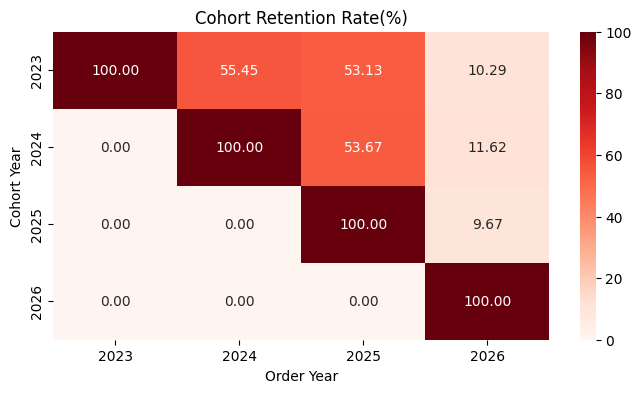

In [93]:
pivot_retention = (
    df_retention.pivot_table(
    index='Cohort_Year',
    columns='Order_Year',
    values='Retention_Rate',
    fill_value=0
))

plt.figure(figsize=(8,4))
sns.heatmap(pivot_retention, annot=True, fmt=".2f", cmap='Reds')
plt.title('Cohort Retention Rate(%)')
plt.ylabel('Cohort Year')
plt.xlabel('Order Year')
plt.show()

**Résultat**

La rétention moyenne observée est de ~54 % entre les années post-acquisition, avec une diminution progressive des cohortes plus anciennes. Les cohortes récentes affichent ~10 % de rétention, car elles sont encore en cours.

Cela confirme que :

* La base client est majoritairement occasionnelle.

* La croissance future dépend surtout de la capacité à renouveler l’acquisition ou à améliorer la rétention, et de la transformation des occasionnels en récurrents.

_________

**4. L’analyse de variation de fréquence**

In [33]:
#condition
existing_customers = (
    customer_year_frequency[
        customer_year_frequency['Order_Year'] > 
        customer_year_frequency['Cohort_Year']
        ]
)
existing_frequency = (
    existing_customers
    .groupby('Order_Year')
    .agg(
        Avg_Orders = ('Orders','mean'),
        Median_Orders = ('Orders','median'),
        Active_Customers = ('Customer_ID','nunique')
    ).reset_index()
)
existing_frequency

,Order_Year,Avg_Orders,Median_Orders,Active_Customers
0,2024,1.465150,1.0,1363
1,2025,1.436119,1.0,2082
2,2026,1.075157,1.0,479


In [34]:
pivot_frequency = (
    existing_customers
    .pivot_table(
        index='Customer_ID',
        columns='Order_Year',
        values='Orders',
        fill_value=0
    )
)
pivot_frequency['Frequency_Diff_25_24'] = (
    pivot_frequency[2025] - pivot_frequency[2024]
)
pivot_frequency['Status_Frequency'] = np.where(
    pivot_frequency['Frequency_Diff_25_24'] > 0,
    'Positif',
    np.where(
        pivot_frequency['Frequency_Diff_25_24'] < 0,
        'Negatif',
        'Stable'
    )
)
pivot_frequency['Status_Frequency'].value_counts().reset_index()

,Status_Frequency,count
0,Positif,1507
1,Negatif,810
2,Stable,567


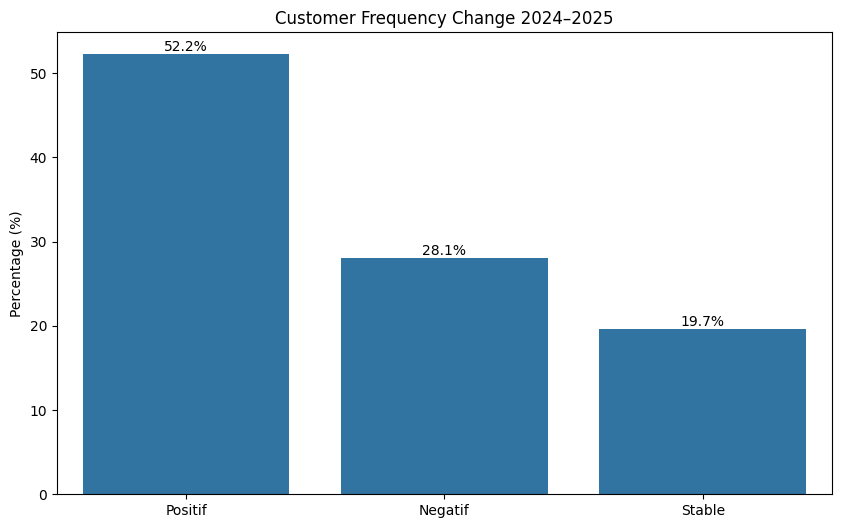

In [35]:
status_frequency_24_25_pct = ((
    pivot_frequency['Status_Frequency']
    .value_counts(normalize=True)*100)
    .reset_index()
).round(2)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=status_frequency_24_25_pct, x='Status_Frequency', y='proportion')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge') 
plt.title('Customer Frequency Change 2024–2025')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.show()

**Interprétation**

Entre 2024-2025 : 

* 1507 clients commandent plus, soit ~52%.
* 810 commandent moins, soit ~28%.
* 567 restent stable, soit ~20%.

In [36]:
pivot_frequency['Frequency_Diff_25_24'].agg(
    ['mean', 
    'median']
    ).round(2).reset_index().transpose()

,0,1
index,mean,median
Frequency_Diff_25_24,0.34,1.0


**Conclusion provisoire**

Entre 2024 et 2025, parmi les clients post-acquisition, 1507 augmentent leur nombre de commandes, 810 diminuent et 567 restent stables.

Cependant, la variation moyenne reste faible (+0.34 commande), ce qui indique une augmentation légère mais non structurelle du comportement d’achat.

La médiane à 1 correspond au scénario le plus fréquent : un client passe une commande supplémentaire par an.

La croissance de la fréquence existe, mais elle reste limitée en intensité.


____________

##### 4.4.2 Impact de la variation de fréquence sur le chiffre d’affaires

Objectif :

- Mesurer si l’évolution du nombre de commandes des clients existants se traduit par une variation de leur contribution au chiffre d’affaires.

________

**1. Variation du chiffre d'affaires des clients existants**

In [37]:
pivot_revenue = (
    existing_customers
    .pivot_table(
        index='Customer_ID',
        columns='Order_Year',
        values='Revenue',
        fill_value=0
    )
)
pivot_revenue['Revenue_Diff_25_24'] = (
    pivot_revenue[2025] - pivot_revenue[2024]
)
pivot_revenue['Status_Revenue'] = np.where(
    pivot_revenue['Revenue_Diff_25_24'] > 0,
    'Growth',
    np.where(
        pivot_revenue['Revenue_Diff_25_24'] < 0,
        'Decline',
        'Stable'
    )
)
pivot_revenue.head()

Order_Year,2024,2025,2026,Revenue_Diff_25_24,Status_Revenue
Customer_ID,,,,,
1,19997.40,826.60,0.0,-19170.80,Decline
2,0.00,1970.04,0.0,1970.04,Growth
4,0.00,242.23,0.0,242.23,Growth
6,1970.83,0.00,0.0,-1970.83,Decline
8,0.00,1970.66,0.0,1970.66,Growth


In [38]:
count = (pivot_revenue['Status_Revenue']
    .value_counts()
)
percentage = (pivot_revenue['Status_Revenue']
    .value_counts(normalize=True)
)*100
index = count.index

status_revenue_diff_25_24 = pd.DataFrame(index, columns=['Status_Revenue']) 
status_revenue_diff_25_24['Count'] = count.values
status_revenue_diff_25_24['Percentage'] = percentage.values
status_revenue_diff_25_24.round(2)

,Status_Revenue,Count,Percentage
0,Growth,1715,59.47
1,Decline,975,33.81
2,Stable,194,6.73


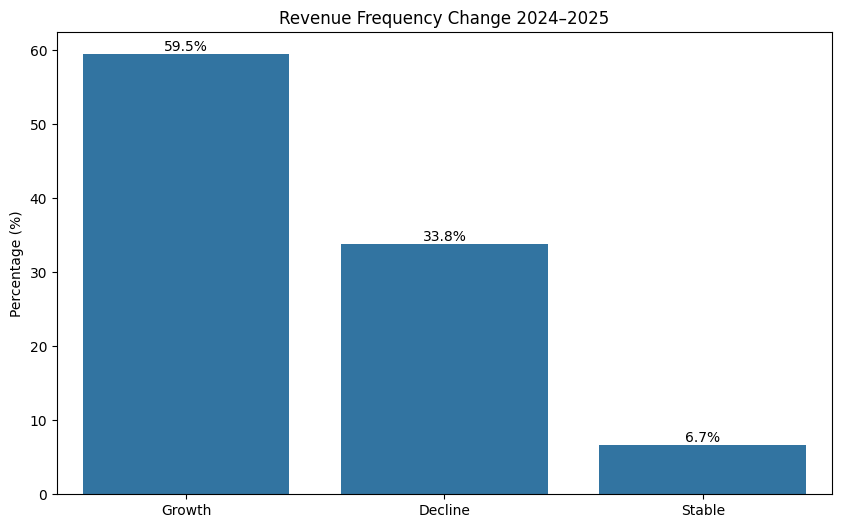

In [39]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=status_revenue_diff_25_24, x='Status_Revenue', y='Percentage')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge') 
plt.title('Revenue Frequency Change 2024–2025')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.show()

Entre 2024-2025 :

* ~59.5% des clients existants ont augmenté leur CA.
* ~34% ont réduit leur CA.
* ~6.8% sont restés stables.

Ce qu'indique une dynamique globale de croissance parmi les clients existants.

________________

**2. Corrélation entre variation de fréquence et variation de revenu**

In [40]:
#corrélation fréquence vs CA
analysis = (
    pivot_frequency[['Frequency_Diff_25_24']]
    .merge(pivot_revenue[['Revenue_Diff_25_24']], on='Customer_ID', how='inner')
)
analysis.corr()

Order_Year,Frequency_Diff_25_24,Revenue_Diff_25_24
Order_Year,,
Frequency_Diff_25_24,1.000000,0.488092
Revenue_Diff_25_24,0.488092,1.000000


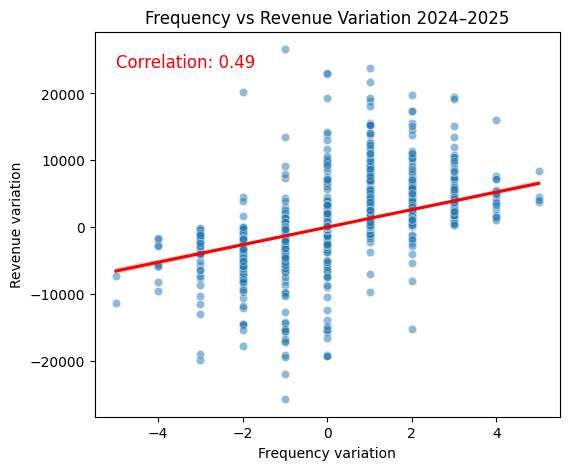

In [86]:
#scatter plot + droite de régression lineaire
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=analysis,
    x='Frequency_Diff_25_24',
    y='Revenue_Diff_25_24',
    alpha=0.5
)

sns.regplot(
    data=analysis,
    x='Frequency_Diff_25_24',
    y='Revenue_Diff_25_24',
    scatter=False,
    color='red'
)

plt.title('Frequency vs Revenue Variation 2024–2025')
plt.xlabel('Frequency variation')
plt.ylabel('Revenue variation')
plt.text(
    x=analysis['Frequency_Diff_25_24'].min(),
    y=analysis['Revenue_Diff_25_24'].max()*0.9,
    s=f"Correlation: {analysis.corr().iloc[0,1]:.2f}",
    fontsize=12,
    color='red'
)
plt.show()

La droite de régression montre la tendance générale croissance, ce qui illustre une corrélation modérée.

Les points individuels sont très dispersés, car la variation du chiffre d'affaires dépend de beaucoup d’autres facteurs que la fréquence.

**Interprétation**

* La corrélation entre la variation de fréquence et la variation du chiffre d’affaires est de ~0.49. 

* Il s’agit d’une corrélation positive modérée, ce qui signifie que les deux variables évoluent dans le même sens. Cependant, cette relation n'est pas dominante.

* Environ **24 % de la variation du revenu** peut être associée à l'évolution de la fréquence de commande (r² = ~0.24).

La corrélation positive modérée, de ~0.49, indique que la variation de fréquence explique ~24 % de la variation du chiffre d’affaires, donc elle joue un rôle secondaire.

**Conclusion**

L’augmentation de la fréquence contribue partiellement à la croissance du chiffre d’affaires des clients existants. 

Cependant, la relation reste modérée, ce qui indique que 76% sont dus à d’autres facteurs, comme le panier moyen ou le mix produit.

La [section suivante](#45-explication-formelle-du-skew) permettra d’analyser la concentration du chiffre d’affaires afin d’identifier un éventuel effet de skew et de comprendre s’il est principalement porté par une minorité de clients ou par certains produits.

_____________

#### 4.5 Explication formelle du skew

Objectif :

- Identifier l’origine de l'asymétrie du chiffre d’affaires et déterminer si une minorité de clients ou certains produits concentrent la majorité des revenus.

______

##### 4.5.1 Concentration du chiffre d'affaires : Gros acheteurs

Objectif :

- Analyser la distribution du chiffre d’affaires entre les clients afin d’identifier si une part importante du revenu est concentrée sur une minorité de gros acheteurs et d’en mesurer l’ampleur.

In [41]:
#échantillon gros acheteurs
df_high_value_subset = df_rfm[df_rfm['Monetary_Net'] > 10000].copy()

#variables
high_value_total_customers = df_high_value_subset['Customer_ID'].nunique()
high_value_total_revenue = df_high_value_subset['Monetary_Net'].sum()

#share
high_value_customers_share = ((high_value_total_customers/total_customers)*100)
high_value_revenue_share = ((high_value_total_revenue/net_revenue)*100)


high_value_overview = pd.DataFrame({
    'High Value Customers':[
        'Total Customers',
        'Customers Share(%)',
        'Total Revenue',
        'Revenue Share(%)'
    ],

    'Values':[
        high_value_total_customers,
        high_value_customers_share,
        high_value_total_revenue,
        high_value_revenue_share
    ]
})
high_value_overview.round(2)

,High Value Customers,Values
0,Total Customers,314.00
1,Customers Share(%),6.87
2,Total Revenue,4953997.35
3,Revenue Share(%),31.13


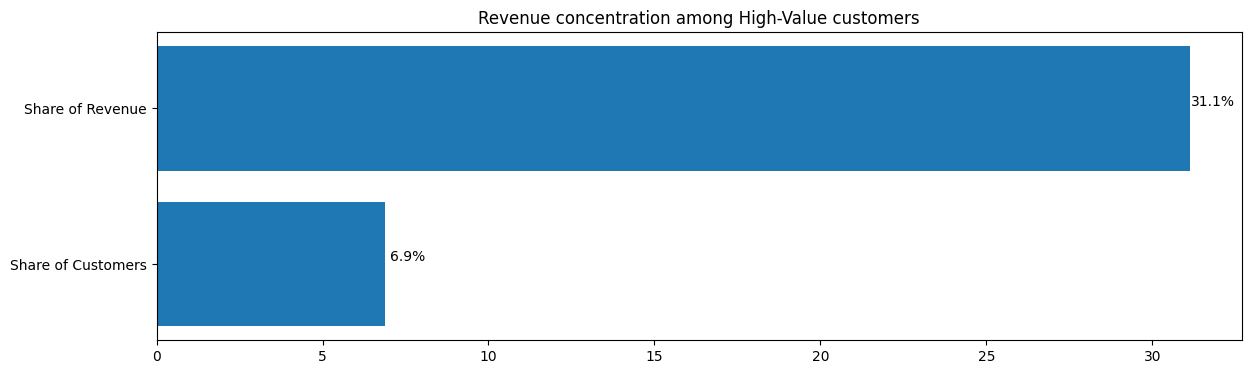

In [207]:
labels = ['Share of Customers','Share of Revenue']
values= [high_value_customers_share, high_value_revenue_share]
plt.figure(figsize=(14,4))
plt.barh(labels, values)
plt.ylabel('')
plt.title('Revenue concentration among High-Value customers')

for i, v in enumerate(values):
    plt.text(v+0.7, i, f"{v:.1f}%", ha='center', va='bottom')

plt.show()

Ce graphique montre clairement la concentration du revenu sur un petit segment de clients.

**Interprétation**

Les gros acheteurs représentent ~6.9% du total des clients existants et participent à environ 31% du chiffre d'affaires global, ce qui montre une concentration significative du CA sur un petit segment.

Cela confirme l’existence d’un skew client : peu de clients concentrent une part disproportionnée du revenu.

___________

##### 4.5.2 Concentration annuelle des gros acheteurs

In [44]:
high_value_annual_overview = (
    df_high_value_subset
    .groupby('Cohort_Year')
    .agg(
        Total_Customers = ('Customer_ID','nunique'), 
        Total_Revenue = ('Monetary_Net','sum')
        )
        .reset_index()
)

high_value_annual_overview['Revenue_%'] = ((
    high_value_annual_overview['Total_Revenue']/
    high_value_total_revenue)
    *100
)
high_value_annual_overview['Grand_Revenue_%'] = ((
    high_value_annual_overview['Total_Revenue']/
    net_revenue)
    *100
)

high_value_annual_overview.round(2)

,Cohort_Year,Total_Customers,Total_Revenue,Revenue_%,Grand_Revenue_%
0,2023,220,3526075.28,71.18,22.16
1,2024,71,1076397.07,21.73,6.76
2,2025,21,311882.80,6.30,1.96
3,2026,2,39642.20,0.80,0.25


**Interprétation**

La majorité des gros acheteurs (220 clients) provient de la cohorte 2023 et génère 71 % du revenu total du segment (~22% du CA global).

Néanmoins, leur contribution diminue considérablement après 2023 :

* 2024 → 21,7 % du segment, 6,8 % du CA global
* 2025 → 6,3 % du segment, 2 % du CA global
* 2026 → 0,8 % du segment, 0,25 % du CA global

**Conclusion**

La concentration des gros acheteurs est historiquement dominée par la cohorte 2023. 

La majorité des revenus du segment provient de cette première vague, et la contribution des cohortes suivantes est marginale.

___________

##### 4.5.3 Répartition des gros acheteurs par segment de fréquence

In [45]:
#répartition de gros acheteurs par segment de fréquence

high_value_customers_frequency = (
    df_high_value_subset
    .groupby('Frequency_Seg')
    .agg(
        Total_Customers = ('Customer_ID','nunique'), 
        Total_Revenue = ('Monetary_Net','sum')
        )
).reset_index()

high_value_customers_frequency['Customer%'] = (
    high_value_customers_frequency['Total_Customers']/
    high_value_total_customers
   *100
)

high_value_customers_frequency['Revenue_%'] = ((
    high_value_customers_frequency['Total_Revenue']/
    high_value_total_revenue)
    *100
)

high_value_customers_frequency['Grand_Revenue_%'] = ((
    high_value_customers_frequency['Total_Revenue']/
    net_revenue)
    *100
)

high_value_customers_frequency.round(2)

,Frequency_Seg,Total_Customers,Total_Revenue,Customer%,Revenue_%,Grand_Revenue_%
0,Occasional,200,3183453.37,63.69,64.26,20.01
1,One-timer,14,220217.48,4.46,4.45,1.38
2,Recurrent,100,1550326.50,31.85,31.29,9.74


**Interprétation**

* Les gros acheteurs Occasional sont majoritaires (63,7 % des clients), contribuant à 64 % du CA du segment, soit 20 % du CA global.

* Les gros acheteurs Recurrent représentent 31,8 % des clients, avec 31 % du CA du segment (~9,7 % du CA global).

* Les One-timers sont très minoritaires (4,5 %), avec un impact marginal sur le CA.

**Conclusion provisoire**

* Le skew du chiffre d’affaires est principalement lié à des gros paniers atteignant >10k €, souvent obtenus par des clients occasionnels plutôt que par des clients très fréquents.

* Il est historiquement concentré dans la phase d’expansion initiale (2023).

___________

##### 4.5.4 Rôle des produits premium dans le skew

Objectif :

- Comprendre la structure produit du business. 

- Vérifier la dépendance globale aux produits Premium.

________

**1. Analyse produit globale**

In [46]:
fact_sales_product_af_2023 = (
    fact_sales
    .loc[lambda df: df['Order_Date'] >= pd.Timestamp('2023-01-01')]
    .merge(dim_products, on='Product_ID', how='left')
    .merge(dim_date, on='Order_Date', how='left')
)

In [47]:
df_price_buckets = fact_sales_product_af_2023.groupby('Price_Buckets').agg(
    Total = ('Customer_ID','count'),
    Revenue = ('Total_Net','sum'),
    Units = ('Quantity','sum')
)
df_price_buckets['Total_%'] = df_price_buckets['Total']/df_price_buckets['Total'].sum()*100
df_price_buckets['Revenue_%'] = df_price_buckets['Revenue']/net_revenue*100
df_price_buckets['Units_%'] = df_price_buckets['Units']/total_units*100
df_price_buckets.round(2)

,Total,Revenue,Units,Total_%,Revenue_%,Units_%
Price_Buckets,,,,,,
High,6395,5806848.25,21071,18.05,36.49,18.48
Low,15768,1407838.39,50033,44.50,8.85,43.89
Mid,10854,2631465.93,35207,30.63,16.54,30.88
Premium,2418,6065276.87,7698,6.82,38.12,6.75


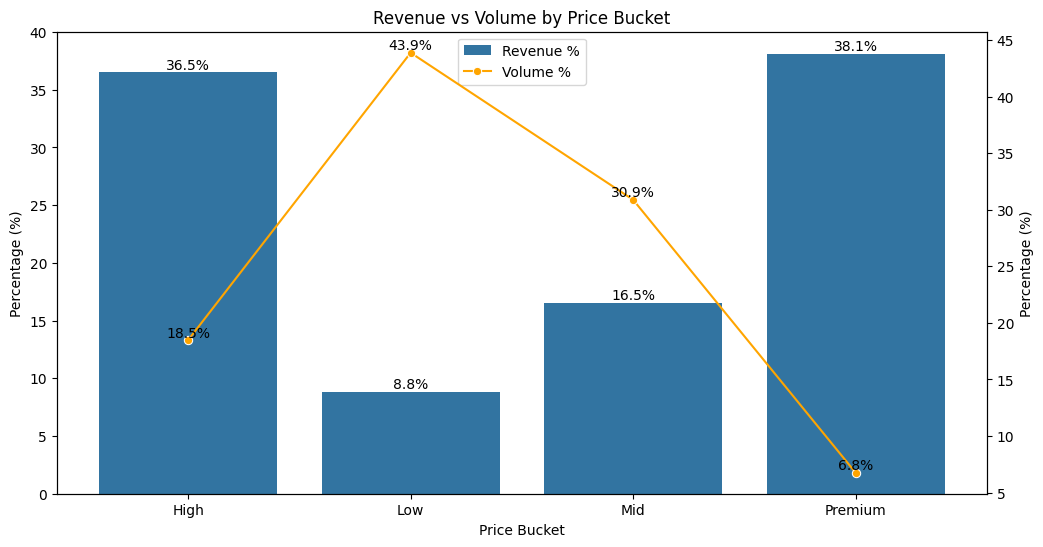

In [194]:
#visualisation contribution revenue vs volume par bucket de prix
fig, ax1 = plt.subplots(figsize=(12,6))
#axe primaire %CA
sns.barplot(data=df_price_buckets, x='Price_Buckets', y='Revenue_%', label='Revenue %', ax=ax1)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='edge')

#axe secondaire %units
ax2 = ax1.twinx()
sns.lineplot(data=df_price_buckets, x='Price_Buckets', y='Units_%', label='Volume %', color='orange', marker='o', ax=ax2, legend=False)
for i, value in enumerate(df_price_buckets['Units_%']):
    ax2.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.title('Revenue vs Volume by Price Bucket')
ax1.set_xlabel('Price Bucket')
ax1.set_ylabel('Percentage (%)')
ax2.set_ylabel('Percentage (%)')

#legende combinée
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper center')

plt.show()

**Interprétation**

Structure produit

* Les produits Premium représentent seulement 6,8 % du volume, mais 38 % du CA global (forte valeur unitaire).

* Les produits High (haut de gamme) représentent 36 % du CA global.

* Les produits Low et Mid représentent la majorité des ventes en volume, mais contribuent moins au CA global (Low 8,85 %, Mid 16,54 %).

**Conclusion**

Bien que le volume des ventes soit majoritairement composé de produits Low et Mid, la concentration du chiffre d’affaires sur les segments High et Premium révèle un skew structurel, principalement lié au prix unitaire élevé des produits Premium.

Le skew est donc produit-driven, fortement concentré sur Premium et High, et non sur la quantité.

____________

**2. Analyse produit chez le gros acheteur**

Objectif :

- Comprendre la concentration du chiffre d'affaires chez les gros acheteurs.

- Voir quel rôle jouent les différentes catégories de prix dans leur CA.

In [49]:
df_high_value_subset = df_high_value_subset.copy()

high_value_customers_product = (
    fact_sales_product_af_2023
    .merge(
        df_high_value_subset, 
        on='Customer_ID', 
        how='inner'
        )
)
high_value_subset = (
    high_value_customers_product[
        [
        'Order_ID', 
        'Customer_ID',
        'Order_Date',
        'Order_Year', 
        'Quantity',
        'Total_Net', 
        'Cohort_Year', 
        'Monetary_Net',
        'Price_Buckets'
        ]
    ]
)  

In [50]:
#validation de la jointure
high_value_subset['Customer_ID'].nunique()

314

In [51]:
#hv = high value
df_hv_price_buckets = high_value_subset.groupby('Price_Buckets').agg(
    Total = ('Customer_ID','count'),
    Units = ('Quantity','sum'),
    Revenue = ('Total_Net','sum')
)

df_hv_price_buckets['Total_%'] = df_hv_price_buckets['Total']/df_hv_price_buckets['Total'].sum()*100
df_hv_price_buckets['Units_%'] = df_hv_price_buckets['Units']/total_units*100
df_hv_price_buckets['Revenue_%'] = df_hv_price_buckets['Revenue'] / high_value_total_revenue * 100
df_hv_price_buckets['Grand_Revenue_%'] = df_hv_price_buckets['Revenue']/net_revenue*100

df_hv_price_buckets.round(2)

,Total,Units,Revenue,Total_%,Units_%,Revenue_%,Grand_Revenue_%
Price_Buckets,,,,,,,
High,762,4186,1377976.19,19.45,3.67,27.82,8.66
Low,1557,4894,140879.29,39.75,4.29,2.84,0.89
Mid,1121,4137,315236.20,28.62,3.63,6.36,1.98
Premium,477,3837,3119905.67,12.18,3.37,62.98,19.61


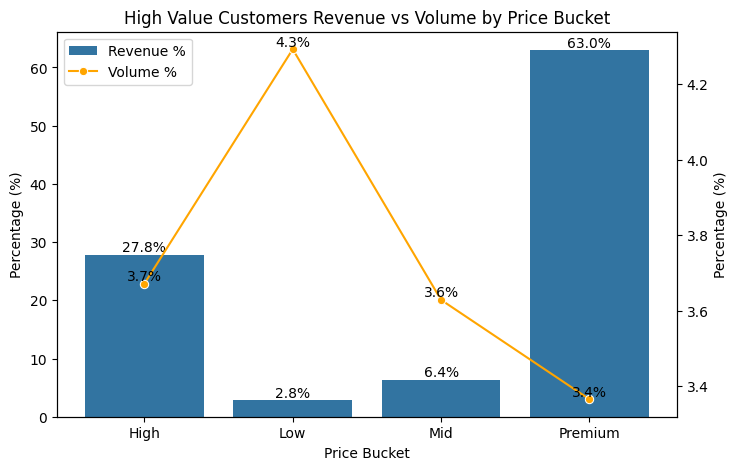

In [180]:
#visualisation de la contribution des gros acheteurs par segment de prix
fig, ax1 = plt.subplots(figsize=(8,5))

#axe primaire %CA
sns.barplot(data=df_hv_price_buckets, x='Price_Buckets', y='Revenue_%', label='Revenue %', ax=ax1)
#ajout des labels de pourcentage sur les barres
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='edge')

#axe secondaire %units
ax2 = ax1.twinx()
sns.lineplot(data=df_hv_price_buckets, x='Price_Buckets', y='Units_%', label='Volume %', ax=ax2, color='orange', marker='o', legend=False)
#ajout des labels de pourcentage sur les points de la ligne
for i, v in enumerate(df_hv_price_buckets['Units_%']):
    ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.title('High Value Customers Revenue vs Volume by Price Bucket')
ax1.set_xlabel('Price Bucket')
ax1.set_ylabel('Percentage (%)')
ax2.set_ylabel('Percentage (%)')

#legende combinée
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2)

plt.show()

**Interprétation**

Les produits Premium correspondent à 12% des commandes des gros acheteurs, ou soit 63% du CA du segment et 19.6% du CA global.

Les produits High sont aussi importants, mais moins que Premium (28% du CA segment).

**Conclusion**

Chez les gros acheteurs, le skew du chiffre d’affaires est accentué par les produits Premium : bien qu’ils ne représentent que 12 % des commandes, ils constituent près de 63 % du CA du segment, confirmant que la **concentration du chiffre d’affaires est principalement produit-driven** et non strictement liée à la fréquence des achats.

_____________

**3. Distribution du CA par catégorie de prix par client dans le temps**

Objectif:

- Identifier comment chaque catégorie de prix contribue au chiffre d’affaires annuel par client.

- Vérifier l’effet des produits Premium sur le CA global sur plusieurs années.

In [53]:
rfm_customers_product = (
    fact_sales_product_af_2023
    .merge(
        df_rfm, 
        on='Customer_ID', 
        how='inner'
        )
)

In [54]:
#validation de la jointure
rfm_customers_product['Customer_ID'].nunique()

4568

In [55]:
# Revenue per Price_bucket per year
price_bucket_revenue_over_years = (
    rfm_customers_product
    .groupby(['Order_Year','Price_Buckets'])
    .agg(
        Total_Customers = ('Customer_ID','nunique'),
        Total_Units = ('Quantity', 'sum'),
        Total_Orders = ('Total_Net','count'),
        Avg_Revenue = ('Total_Net','mean'),
        Total_Revenue = ('Total_Net','sum')
)
).round(2)

price_bucket_revenue_over_years = price_bucket_revenue_over_years.reset_index()
price_bucket_revenue_over_years = (
    price_bucket_revenue_over_years
    .merge(annual_revenue, on='Order_Year')
)

price_bucket_revenue_over_years['Revenue_%'] = (
    (
    price_bucket_revenue_over_years['Total_Revenue']/
    price_bucket_revenue_over_years['Annual_Revenue']
    *100
    )
).round(2)

price_bucket_revenue_over_years

,Order_Year,Price_Buckets,Total_Customers,Total_Units,Total_Orders,Avg_Revenue,Total_Revenue,Annual_Revenue,Revenue_%
0,2023,High,1251,5972,1813,889.37,1612429.71,4385580.67,36.77
1,2023,Low,2036,14292,4518,88.21,398534.02,4385580.67,9.09
2,2023,Mid,1739,9700,3084,238.00,733982.91,4385580.67,16.74
3,2023,Premium,564,2059,663,2474.56,1640634.03,4385580.67,37.41
4,2024,High,1499,7108,2194,889.91,1952473.14,5464140.25,35.73
5,2024,Low,2352,16926,5363,89.47,479846.32,5464140.25,8.78
6,2024,Mid,1982,12555,3738,249.15,931321.45,5464140.25,17.04
7,2024,Premium,705,2682,825,2546.06,2100499.34,5464140.25,38.44
8,2025,High,1397,6807,2057,926.50,1905802.27,5256684.99,36.25
9,2025,Low,2223,16183,5108,89.48,457044.60,5256684.99,8.69


**Interprétation**

* Le chiffre d’affaires annuel est dominé par les produits High et Premium (~75–80 %). 

* Le segment Premium est la principale source du skew, contribuant régulièrement >37 % du CA annuel.

* Le panier moyen qui contient des produits Premium augment considérablement par rapport les autres catégories-prix.

* Le volume de ventes des catégories Low et Mid est élevé mais ne contribue que faiblement au CA.

________

**4. Récapitulatif du rôle des produits dans la concentration du CA dans le temps**

Objectif :

- Synthétiser l’impact de chaque catégorie de prix sur le chiffre d’affaires annuel.

- Confirmer la contribution du segment Premium au skew.

In [56]:
#summary rôle des produits dans la concentration du CA dans le temps
price_bucket_revenue_over_years.pivot_table(
    index='Price_Buckets',
    columns='Order_Year',
    values='Revenue_%'
).round(2)

Order_Year,2023,2024,2025,2026
Price_Buckets,,,,
High,36.77,35.73,36.25,41.76
Low,9.09,8.78,8.69,9.00
Mid,16.74,17.04,16.00,15.56
Premium,37.41,38.44,39.05,33.69


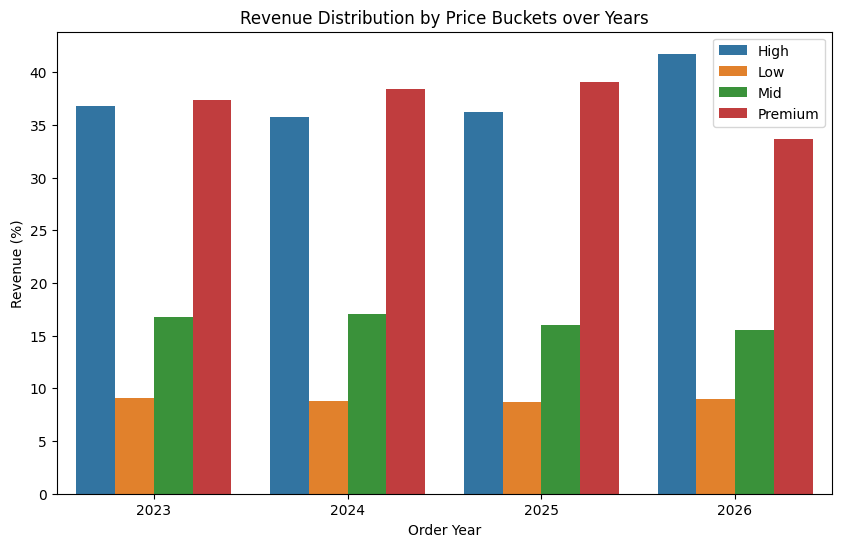

In [119]:
plt.figure(figsize=(10,6))
sns.barplot(data=price_bucket_revenue_over_years, x='Order_Year', y='Revenue_%', hue='Price_Buckets')
plt.title('Revenue Distribution by Price Buckets over Years')
plt.xlabel('Order Year')
plt.ylabel('Revenue (%)')
plt.legend(loc='upper right')
plt.show()

**Interprétation**

* High + Premium représentent 75–80 % du CA annuel, confirmant la forte concentration sur le haut de gamme.

* La catégorie-prix Premium est la plus représentative, et reste stable entre 37–39 % du CA annuel, même si 2026 est partielle.

**Conclusion**

Le skew ne vient pas du nombre de commandes, mais du ticket unitaire élevé, dominé par les produits des catégories haut de gamme - Premium et High.

___________

**5. Aperçu des produits Premium**

Objectif :

- Analyser les ventes de produits Premium sur les années pour comprendre leur rôle dans le skew et le CA global, à la fois pour l'ensemble des clients et pour les gros acheteurs.

In [58]:
#aperçu des produits Premium
premium_products = (
    price_bucket_revenue_over_years[
        price_bucket_revenue_over_years['Price_Buckets'] == 'Premium']
)
premium_products

,Order_Year,Price_Buckets,Total_Customers,Total_Units,Total_Orders,Avg_Revenue,Total_Revenue,Annual_Revenue,Revenue_%
3,2023,Premium,564,2059,663,2474.56,1640634.03,4385580.67,37.41
7,2024,Premium,705,2682,825,2546.06,2100499.34,5464140.25,38.44
11,2025,Premium,697,2626,811,2531.36,2052935.79,5256684.99,39.05
15,2026,Premium,113,331,119,2279.06,271207.71,805023.53,33.69


**Conclusion finale**

*Structure du CA* : High + Premium représentent ~75–80 % du chiffre d’affaires annuel. Le skew est donc structurellement produit-driven.

*Gros acheteurs (>10k €)* : 6,9 % des clients contribuent à 31 % du CA. La majorité sont Occasional, pas uniquement Recurrent.

*Produit Premium* : 6,8 % des ventes en volume, 38 % du CA global ; chez les gros acheteurs, 12 % des commandes représentent 19,6 % du CA segment. Part stable 36–39 % annuellement (2026 partielle non interprétable).

**Synthèse**

**Le skew est principalement produit-driven (Premium), avec concentration client modérée (gros acheteurs) et historiquement concentré sur la vague d’expansion initiale (2023)**.


_______

#### 4.6 Churn et impact sur le chiffre d'affaires 

Objectif : 

- Mesurer l’effet de la perte de clients sur le CA.

- Identifier les segments à prioriser pour fidélisation.

##### 4.6.1 Segmentation par Récence et taux global de churn

Définition : nombre de jours depuis la dernière commande

Utilité : mesure d'interaction 

Segmentation :

* Active : < = 90 jours

* At Risk : 90-180 jours

* Churned : > = 180 jours

In [59]:
#recency segment 
df_rfm['Recency_Seg'] = np.where(
    df_rfm['Recency'] <= 90,
    'Active',
    np.where(
        df_rfm['Recency'] >= 180,
        'Churned',
        'At Risk'
    )
)
churn_rate = (
    df_rfm['Recency_Seg']
    .value_counts(normalize=True)*100
).round(2)
churn_rate.reset_index()

,Recency_Seg,proportion
0,Churned,64.82
1,Active,19.51
2,At Risk,15.67


**Résultat** 

* ~65% des clients sont churned. 

Cela veut dire qu'une part importante de la base client (~2/3) n’a pas commandé depuis au moins 180 jours. 

La base active reste limitée (~20%), ce qui représente un retour très faible et par conséquent, un **risque de contraction future du chiffre d’affaires si les clients ne sont pas réactivés**.

_________

##### 4.6.2 Churn par cohorte et impact sur le revenu

Objectif : 

- Identifier quelles cohortes contribuent le plus au churn et mesurer leur impact sur le chiffre d'affaires.

In [60]:
#Distribuition
annual_recency_distribution = (
    df_rfm
    .groupby([
        'Cohort_Year',
        'Recency_Seg'
        ])
        .agg(
            Total_Customers = ('Customer_ID','nunique'),
            Total_Revenue = ('Monetary_Net','sum')
            )
            .reset_index()
)

annual_recency_distribution['Customer_%'] = (
    (annual_recency_distribution['Total_Customers']/
    total_customers)*100
).round(2)

annual_recency_distribution['Revenue_%'] = (
    (annual_recency_distribution['Total_Revenue']/
    net_revenue)*100
).round(2)

annual_recency_distribution

,Cohort_Year,Recency_Seg,Total_Customers,Total_Revenue,Customer_%,Revenue_%
0,2023,Active,432,2397937.39,9.46,15.07
1,2023,At Risk,348,1769348.84,7.62,11.12
2,2023,Churned,1678,6049249.32,36.73,38.02
3,2024,Active,258,1053914.16,5.65,6.62
4,2024,At Risk,201,732841.82,4.40,4.61
5,2024,Churned,987,2510055.99,21.61,15.78
6,2025,Active,137,387901.92,3.00,2.44
7,2025,At Risk,167,405077.98,3.66,2.55
8,2025,Churned,296,492622.99,6.48,3.10
9,2026,Active,64,112479.03,1.40,0.71


In [61]:
#impact sur le CA par cohorte
annual_recency_distribution.pivot_table(
    index='Recency_Seg',
    columns='Cohort_Year',
    values='Revenue_%',
    fill_value=0
)

Cohort_Year,2023,2024,2025,2026
Recency_Seg,,,,
Active,15.07,6.62,2.44,0.71
At Risk,11.12,4.61,2.55,0.00
Churned,38.02,15.78,3.10,0.00


In [62]:
churn_share = (
    annual_recency_distribution
    .loc
    [annual_recency_distribution['Recency_Seg'] == 'Churned']
    [['Cohort_Year', 'Recency_Seg','Customer_%','Revenue_%']]
)
churn_share

,Cohort_Year,Recency_Seg,Customer_%,Revenue_%
2,2023,Churned,36.73,38.02
5,2024,Churned,21.61,15.78
8,2025,Churned,6.48,3.10


**Interprétation**

* La cohorte 2023 concentre la majorité du churn : 36.7% des clients totaux et 38% du CA global proviennent des client désormais churned.

* Cette situation s'explique principalement par l'ancienneté de la cohorte 2023, qui a eu plus de temps pour devenir inactive.

* Le churn diminue fortement dans les cohortes plus récentes (2024, 2025), ce qui suggère que **la perte de clients soit notamment liée à la cohorte historique**.


**Conclusion**

La cohorte 2023 concentre la majorité du churn : 36,7 % des clients totaux et 38 % du CA global proviennent de clients désormais churned.


___________

##### 4.6.3 Churn des clients occasionnels 

Objectif :

- Évaluer le poids des clients Occasional churned dans la base client.

In [63]:
frequency_recency_cohort_overview = (
    df_rfm
    .groupby([
        'Cohort_Year',
        'Frequency_Seg',
        'Recency_Seg'
        ])
        .agg(
            Total_Customers =('Customer_ID', 'nunique'),
            Total_Revenue = ('Monetary_Net', 'sum')
            )
            .reset_index()
)

frequency_recency_cohort_overview['Customer_%'] = (
    (frequency_recency_cohort_overview['Total_Customers']/
    total_customers)*100
).round(2)

frequency_recency_cohort_overview['Revenue_%'] = (
    (frequency_recency_cohort_overview['Total_Revenue']/
    net_revenue)*100
).round(2)

In [132]:
#pourcentage de clients occasionnels churnés dans le total de la base
occasional_churned_overview = (
    frequency_recency_cohort_overview
    .loc[(frequency_recency_cohort_overview['Frequency_Seg'] == 'Occasional') & 
                    (frequency_recency_cohort_overview['Recency_Seg'] == 'Churned')]
                    [['Cohort_Year','Customer_%','Revenue_%']]
)
occasional_churned_overview

,Cohort_Year,Customer_%,Revenue_%
2,2023,26.25,28.42
9,2024,12.48,11.89
16,2025,1.29,1.09


In [133]:
occasional_churned_customer_pct = (
    frequency_recency_cohort_overview.loc[(frequency_recency_cohort_overview['Frequency_Seg']=='Occasional') &
                                    (frequency_recency_cohort_overview['Recency_Seg']=='Churned'), 
                                    'Total_Customers'].sum()/total_customers*100
).round(2)
occasional_churned_customer_pct

np.float64(40.02)

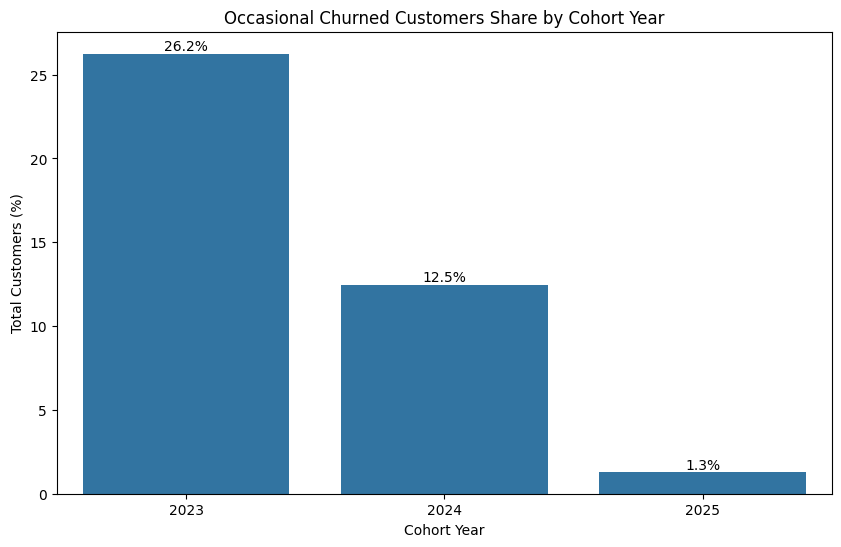

In [151]:
plt.figure(figsize=(10,6))
ax1 = sns.barplot(data=occasional_churned_overview, x='Cohort_Year', y='Customer_%')

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='edge')

plt.title('Occasional Churned Customers Share by Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Total Customers (%)')
plt.show()

**Interprétation**

* 40 % des clients de la base sont Occasional churned. Ce chiffre sert à décrire la structure du churn.
* 26 % proviennent de la cohorte 2023.

La cohorte 2023 représente une part importante du churn global.

In [123]:
total_acquisition_2023 = acquisition_rate[:1]['Total_Customers'].iloc[0]

frequency_occasional = df_frequency[:1]['Total_Customers'].iloc[0]

total_occasional_customers_churned = (
    frequency_recency_cohort_overview.loc[(frequency_recency_cohort_overview['Frequency_Seg'] == 'Occasional') & 
                    (frequency_recency_cohort_overview['Recency_Seg'] == 'Churned'), 'Total_Customers']
    .sum()
)

frequency_recency_cohort_overview_occasional_2023_filter = (
    frequency_recency_cohort_overview[(frequency_recency_cohort_overview['Cohort_Year'] == 2023) & 
                (frequency_recency_cohort_overview['Frequency_Seg'] == 'Occasional')]
)
total_occasional_customers_2023 = (
    frequency_recency_cohort_overview_occasional_2023_filter['Total_Customers']
    .sum()
)
total_occasional_customers_churned_2023 = (
    frequency_recency_cohort_overview_occasional_2023_filter
    .loc[frequency_recency_cohort_overview_occasional_2023_filter['Recency_Seg'] == 'Churned', 'Total_Customers']
    .sum()
)
occasional_customers_churned_2023_share = ((
    total_occasional_customers_churned_2023/
    total_occasional_customers_2023
    )*100
).round(2)

df_occasional_churned = pd.DataFrame({
    'Metric':[
        'Grand Total Customers',
        'Total Customers 2023',
        'Total Occasional Customers',
        'Total Occasional Churned',
        'Total Occasional Customers 2023',
        'Total Occasional Churned Customers 2023',
        'Occasional Churned Customers 2023 Share(%)'
    ],
    'Values':[
        total_customers,
        total_acquisition_2023,
        frequency_occasional,
        total_occasional_customers_churned,
        total_occasional_customers_2023,
        total_occasional_customers_churned_2023,
        occasional_customers_churned_2023_share
    ]
})
df_occasional_churned

,Metric,Values
0,Grand Total Customers,4568.00
1,Total Customers 2023,2458.00
2,Total Occasional Customers,2945.00
3,Total Occasional Churned,1828.00
4,Total Occasional Customers 2023,1743.00
5,Total Occasional Churned Customers 2023,1199.00
6,Occasional Churned Customers 2023 Share(%),68.79


**Interprétation**

Pour la cohorte 2023, le taux de churn des clients Occasional est particulièrement élevé: 

* 69 % des Occasional acquis en 2023 sont aujourd’hui inactifs. Ce chiffre sert à mesurer le risque comportemental.

**Conclusion**

Le churn est fortement concentré dans le segment Occasional : près de 7 clients sur 10 acquis en 2023 (1743) ne sont plus actifs. Ce qui constitue la partie la plus instable de la base.

_________

##### 4.6.4 Impacte du churn sur le chiffre d'affaires (Taux de perte)

Objectif :

- Mesurer la part du chiffre d'affaires associée aux clients chuned et identifier la contribution du segment Occasional.

Méthodologie : 

- Fusion des tableaux Acquisition/Churn/Occasional Churn pour synthèse.

In [67]:
occasional_churn_rate = (
    frequency_recency_cohort_overview[
        (frequency_recency_cohort_overview['Frequency_Seg'] == "Occasional") & 
        (frequency_recency_cohort_overview['Recency_Seg'] == "Churned")
        ]
        [['Cohort_Year', 'Customer_%','Revenue_%']]
        .rename(
            columns={
                'Customer_%':'Occasional_Churned_Customers_%',
                'Revenue_%':'Occasional_Churned_Revenue_%'
            }
        )
)

churn_rate = (
    annual_recency_distribution[
        annual_recency_distribution['Recency_Seg']=='Churned'
        ]
        [['Cohort_Year','Customer_%','Revenue_%']]
        .rename(
            columns={
                'Customer_%':'Churn_Customers_%',
                'Revenue_%':'Churn_Revenue_%'
            }
        )
)

summary_retention = (
    acquisition_rate
    .merge(churn_rate, on='Cohort_Year')
    .merge(occasional_churn_rate, on='Cohort_Year')
)
summary_retention.transpose()

,0,1,2
Cohort_Year,2023.00,2024.00,2025.00
Total_Customers,2458.00,1446.00,600.00
Acquisition_%,53.81,31.65,13.13
Revenue_%,64.21,27.00,8.08
Churn_Customers_%,36.73,21.61,6.48
Churn_Revenue_%,38.02,15.78,3.10
Occasional_Churned_Customers_%,26.25,12.48,1.29
Occasional_Churned_Revenue_%,28.42,11.89,1.09


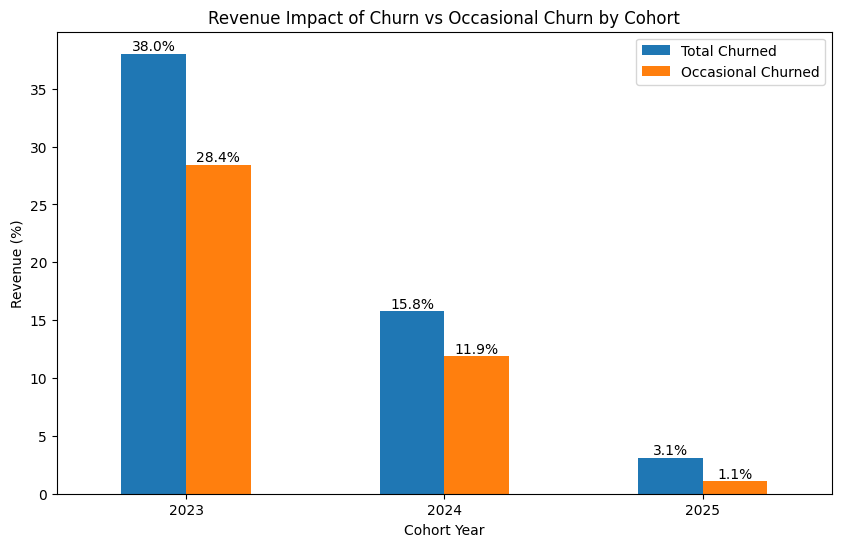

In [112]:
churn_compare = churn_share[['Cohort_Year','Revenue_%']].merge(
    occasional_churned_overview[['Cohort_Year','Revenue_%']],
    on='Cohort_Year'
)

churn_compare.columns = ['Cohort_Year','Churn_Revenue_%','Occasional_Churn_Revenue_%']
ax = churn_compare.set_index('Cohort_Year').plot(
    kind='bar',
    figsize=(10,6)
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')
    
plt.legend(['Total Churned','Occasional Churned'])
plt.ylabel('Revenue (%)')
plt.xlabel('Cohort Year')
plt.title('Revenue Impact of Churn vs Occasional Churn by Cohort')
plt.xticks(rotation=0)
plt.show()

**Interprétation**

La cohorte 2023 concentre l’essentiel de l’impact économique du churn :

* 38 % du chiffre d’affaires global provient de clients aujourd’hui churned.

* 28.42 % du CA global provient uniquement des 69% des clients Occasional churned, ou soit presque 1/3 du revenu vient de clients occasionnels inactifs.

* Churn CA (38.02 %) > Churn clients (36.73 %) : signifie que les clients churned pèsent davantage économiquement que démographiquement.

**Conclusion**

Le churn a un impact direct sur le chiffre d'affaires, lié principalement à la vague d’acquisition 2023, et fortement concentré dans le segment Occasional. **Ce segment constitue donc la principale source de revenu aujourd’hui perdu**.

_________

## 5. Synthèse et insights clés

1. La croissance du chiffre d'affaires est principalement liée à la vague d’acquisition initiale de 2023, qui constitue la base principale du revenu.

2. La fréquence d'achat des clients existants contribue au chiffre d'affaires, mais son impact reste modéré (~24 %).

3. La concentration client existe, mais reste limitée : les gros acheteurs concentrent une part significative du chiffre d'affaires (31%), mais ne sont pas dominants (6.9% des clients).

4. La structure du chiffre d'affaires est fortement produit-driven : les segments Premium/High représentent ~75% du CA.

5. Les produits Premium constituent le principal facteur de skew, avec environ 38% CA annuel.

6. Le Churn élevé des clients Occasional, notamment dans la cohorte 2023, représente un risque structurel pour la croissance future.

________

## 6. Recommandations business

* Réactiver les Occasional churned et les fidéliser (transformation vers Recurrent, proposer des remises, carte fidélité).
* Stratégie d'acquisition des nouveaux clients ciblée.
* Suivi cohorte rétention long terme.
* Récompenser cohorte historique (programme d'ancienneté)
* Encourager la diversification des paniers vers l'achat des produits High/Mid pour réduire dépendance aux Premium.
* Encourager les one-timers à acheter plus fréquemment et proposer des remises sur des produits haute gamme-premium.

La croissance future dépend surtout de la capacité à renouveler l’acquisition ou à améliorer la rétention, et de la transformation des Occasionals en récurrents.

___________

## Conclusion

L'analyse montre que la croissance du chiffre d'affaires repose principalement sur la vague d'acquisition initiale de 2023, qui constitue le socle de la base client.

Les autres facteurs jouent un rôle secondaire :
* La fréquence d’achat contribue au revenu, mais reste modérée (~24 % d’influence).
*  La concentration du chiffre d’affaires sur certains clients existe, mais reste limitée. C'est le cas des gros acheteurs.
* Le mix produit, notamment les segments-produit haute gamme Premium et High, explique grande partie de la dispersion du chiffre d'affaires.

La croissance observée apparaît ainsi comme le résultat combiné :
* d'une forte acquisition initiale,
* et d'un effet produit lié au positionnement haut de gamme,

plutôt que d'une transformation structurelle du comportement d'achat des clients.


______________

## Compétences mobilisées

Le Notebook 2 met en oeuvre plusieurs compétences fondamentales du métier de data analyst :

1. **Data analysis** Analyse de données : nettoyage, agrégation, calcul de KPIs, avec structuration des analyses selon plusieurs axes (clients, produits et périodes temporelles).

2. **Customer segmentation** Segmentation et profilage clients : construction d'indicateurs comportementaux (RFM, cohortes, fréquence d'achat) et mesure de leur contribution au chiffre d’affaires.

3. **Behavior analysis** Analyse des comportements d'achat : étude de l'acquisition et de la rétention, des variations de fréquence, identification du skew de distribution et le rôle des petits segments dans la concentration du chiffre d'affaires.

4. **Visualisation et reporting** : construction des graphiques (barplots, heatmaps, distribution) afin de synthétiser les résultats et structurer l'interprétation métier des données (storytelling).

5. **Business insight** : interprétation analytique des résultats pour identifier des leviers de croissance, notamment le rôle des segments clients et l’impact des produits dans la structure du chiffre d’affaires.